Luca Betti UEVE - M2QF

Ettore Davide Brignoli UEVE - M2QF

# Machine Learning Project
Advice the Director of a mobile phone operator to predict the churn rate of his compagny

The coding for this project is extensive and some of the model investigated are not discussed in the report, we decided to keep them in here anyway to show the research we have done

## Chapter 1 – Data Loading

### 1.1 Import libraries and data

In [1]:
#Installing necessary libraries
!pip install xgboost
!pip install lightgbm
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 11.2 MB/s eta 0:00:00


In [58]:
#Importing all the necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.offline as py
import plotly.express as px
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.stats as stats
import plotly.graph_objects as go
from statsmodels.stats.multivariate import test_cov_oneway

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import BorderlineSMOTE
from collections import Counter

from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

from sklearn import metrics
from sklearn.tree import export_text
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import BaggingClassifier, VotingClassifier

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

import shap

from sklearn.metrics import roc_curve, auc
from scipy.stats import f
from scipy.stats import shapiro
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras import callbacks, optimizers
from sklearn.metrics import ConfusionMatrixDisplay
from tensorflow.keras import metrics

import warnings
warnings.filterwarnings("ignore")

In [3]:
#Getting all the data from the .csv file
data = pd.read_csv('celldata.csv')

#Feature columns
X = data.drop(["Churn"],axis=1)

#Target column
Y = data["Churn"]

In [4]:
#Performing One-Hot Encoding for categorical features
X = pd.get_dummies(X, columns=['Geography'], prefix='Geography', dtype=int)
X = pd.get_dummies(X, columns=['Gender'], prefix='Gender', dtype=int)

names = X.columns
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'Salary']
categorical_features = [col for col in X.columns if col not in numerical_features]

## Chapter 2 – Exploratory Data Analysis

In [5]:
#Calculate Churn rate in the initial dataset
prop_zero = (Y == 0).sum() / len(Y)

# Creating temporary dataframe to plot
plot_df = pd.DataFrame(Y).astype(str)
plot_df.columns = ['Churn_Status']

fig = px.histogram(plot_df, x='Churn_Status',
    title='Distribution of the Churn Rate (Absolute values)',
    labels={
        "Churn_Status": "Churn Status (0: No Churn, 1: Churn)",
        "Count": "Frequence"
    },
    color_discrete_sequence=['#4c78a8', '#f58518']
)

fig.update_layout(xaxis={'categoryorder':'total ascending'})
fig.show()

In [6]:
#Descriptive statistics
data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Salary,Churn
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,650.805000,38.871625,5.013000,76011.635494,1.533625,0.704750,0.515750,100211.396750,0.201125
std,96.721648,10.446006,2.897565,62402.105212,0.583448,0.456184,0.499783,57165.688096,0.400866
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,12.000000,0.000000
25%,584.000000,32.000000,2.000000,0.000000,1.000000,0.000000,0.000000,51464.500000,0.000000
50%,652.000000,37.000000,5.000000,96846.565000,1.000000,1.000000,1.000000,100583.000000,0.000000
75%,718.000000,44.000000,7.000000,127593.625000,2.000000,1.000000,1.000000,149068.000000,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.000000,1.000000


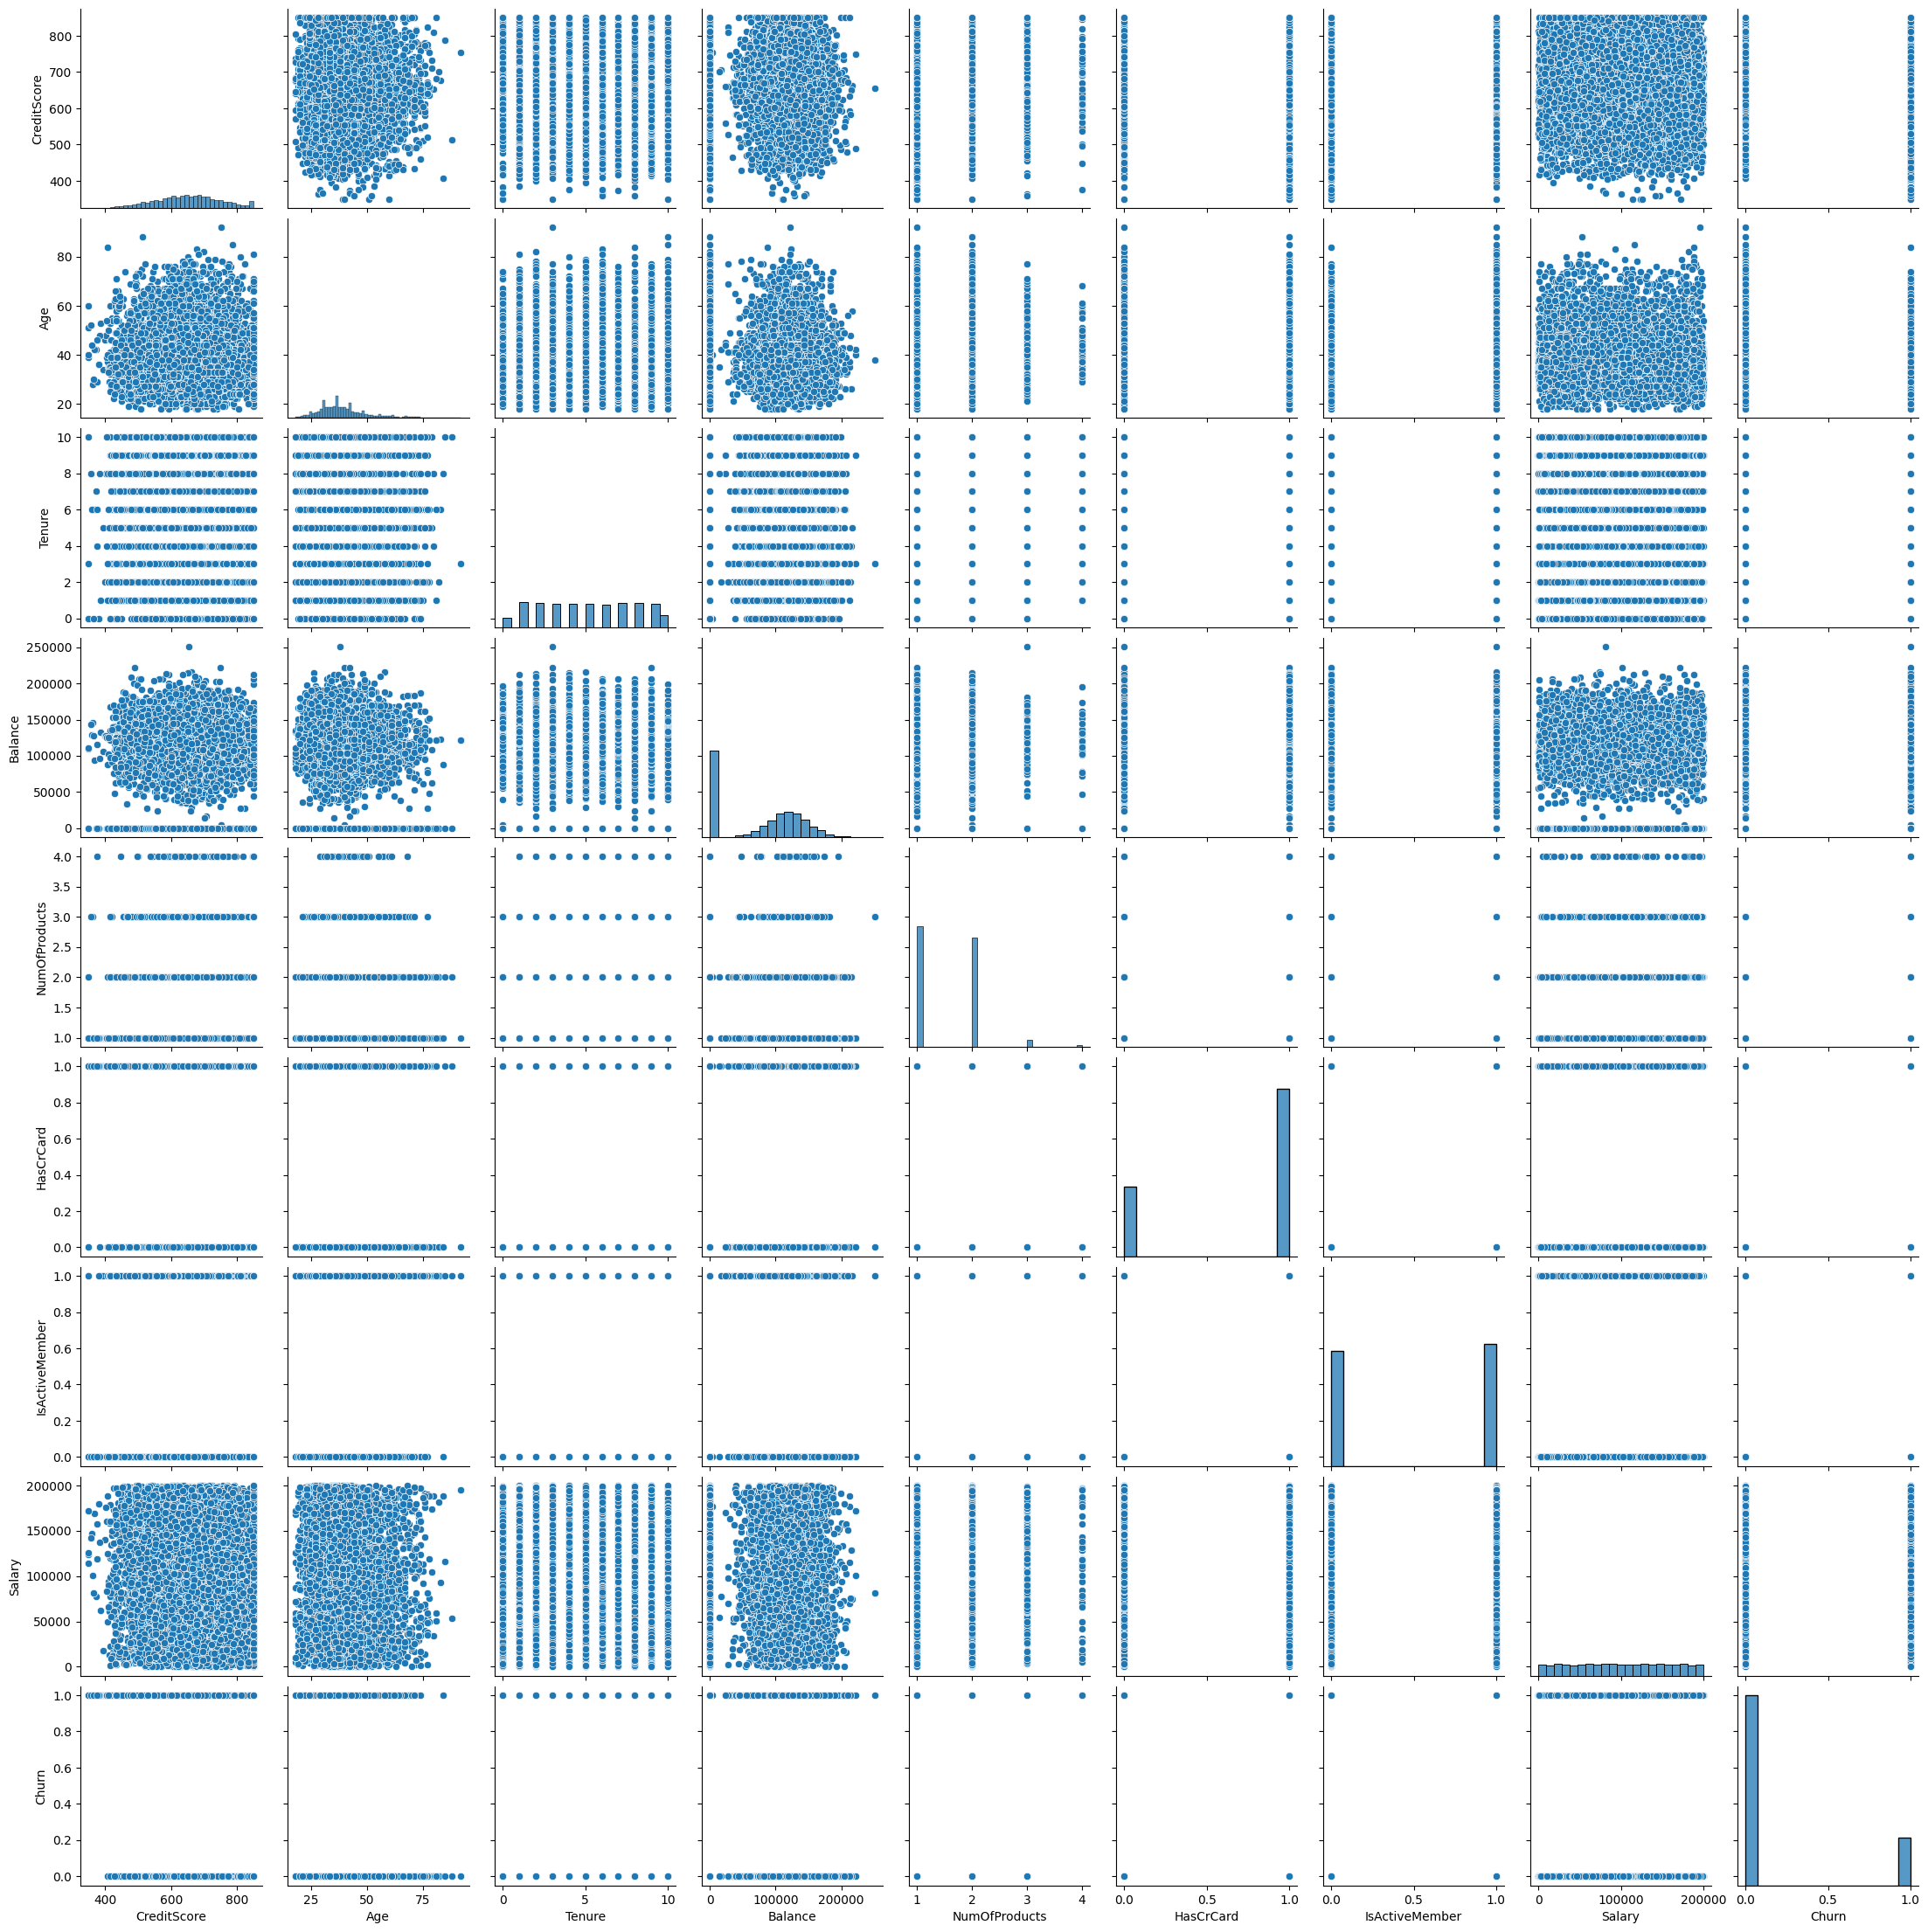

In [7]:
#Plot graphs for every pair of features
sns.pairplot(data);

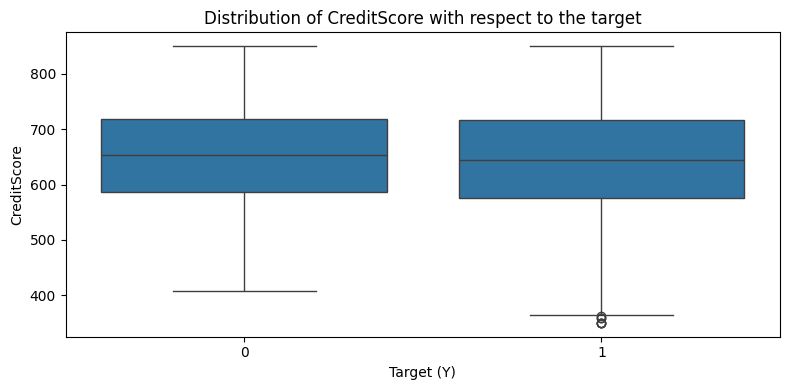

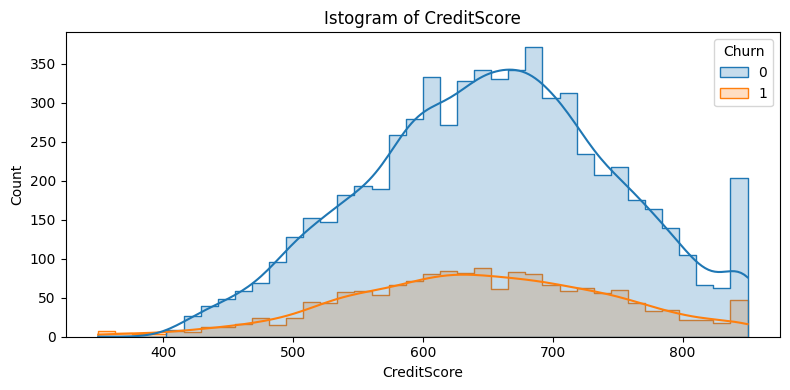

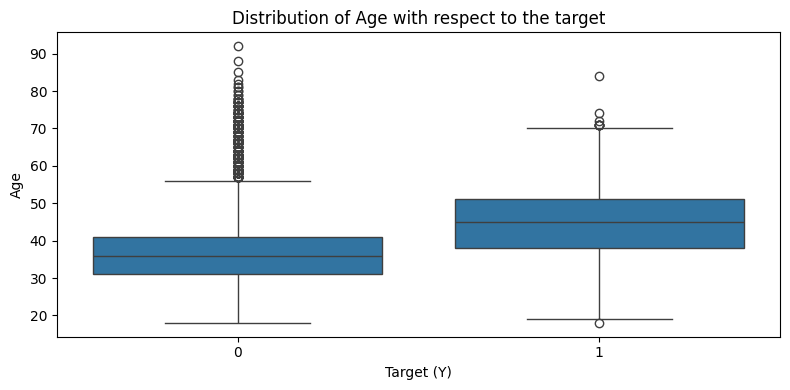

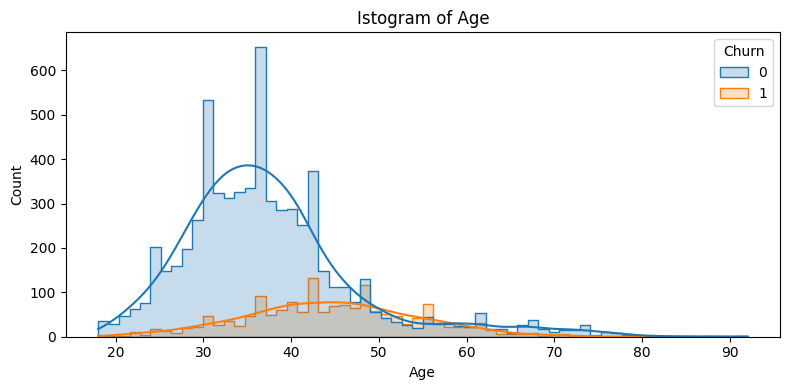

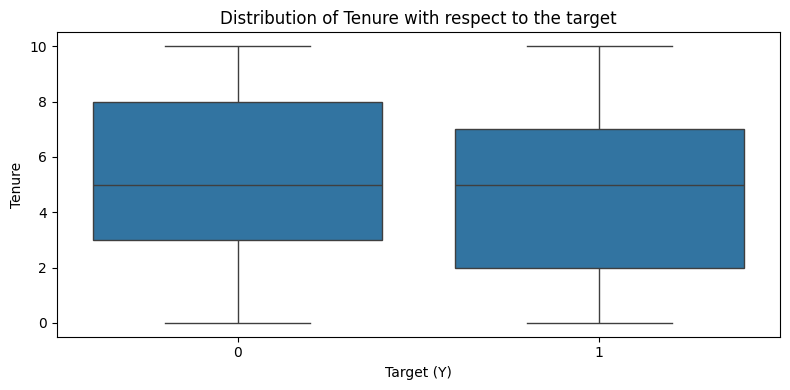

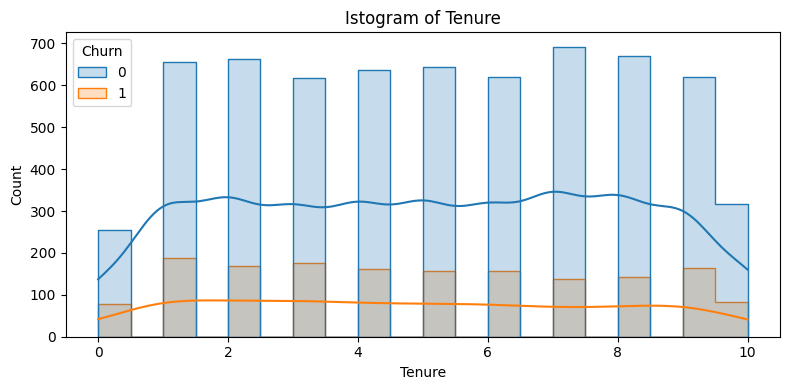

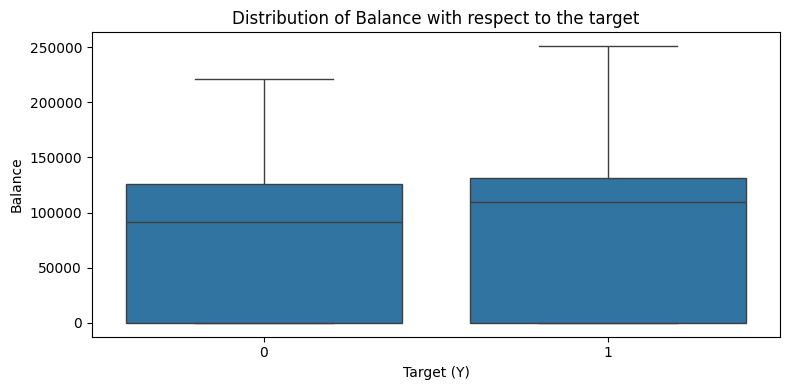

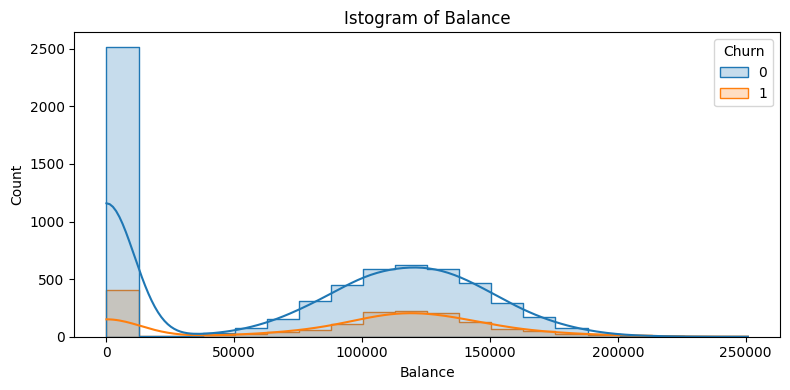

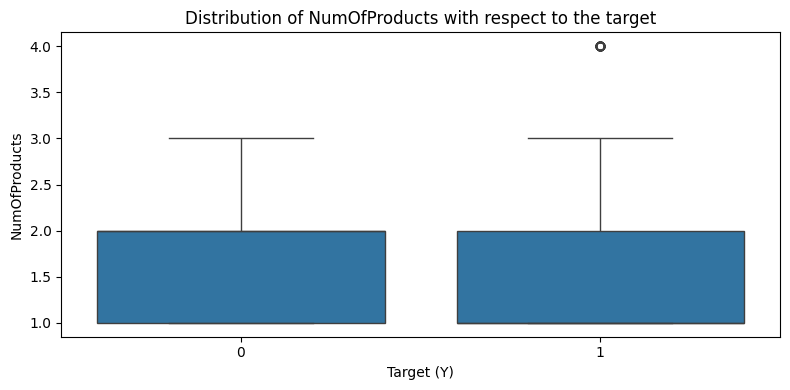

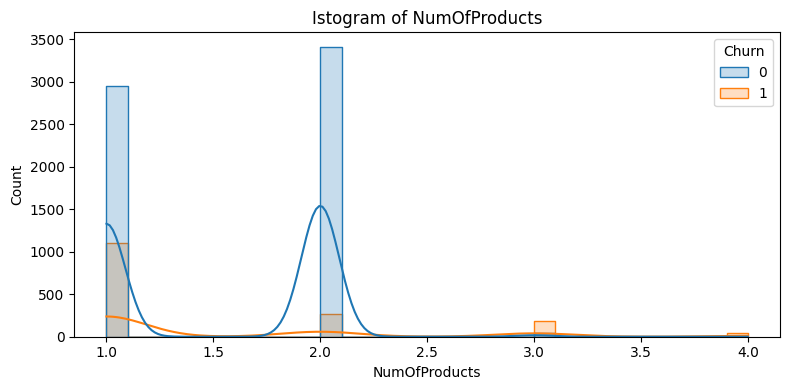

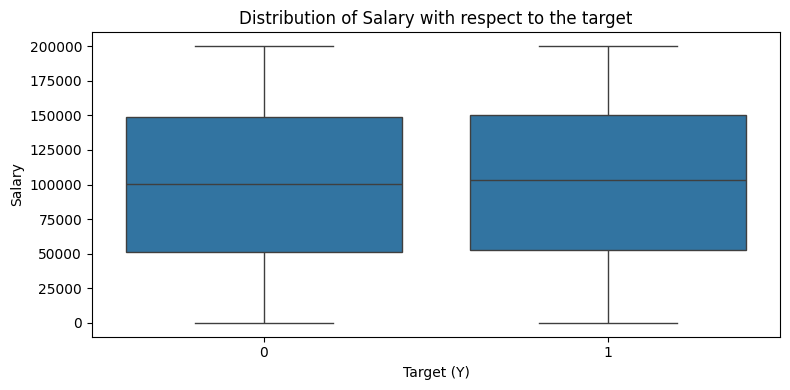

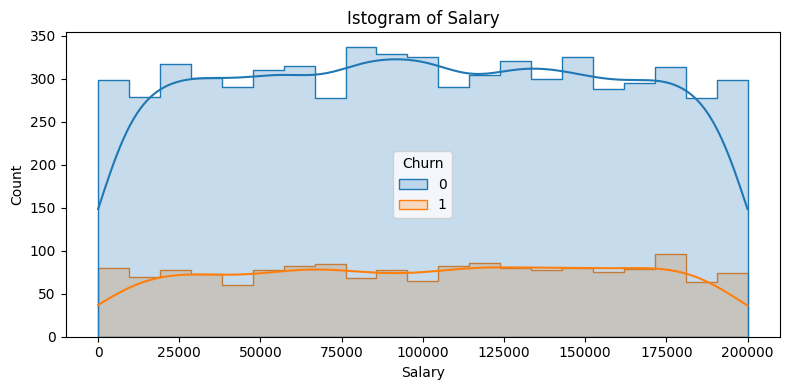

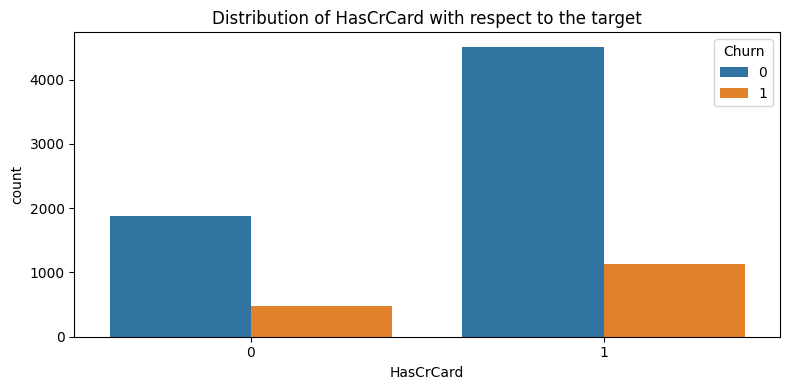

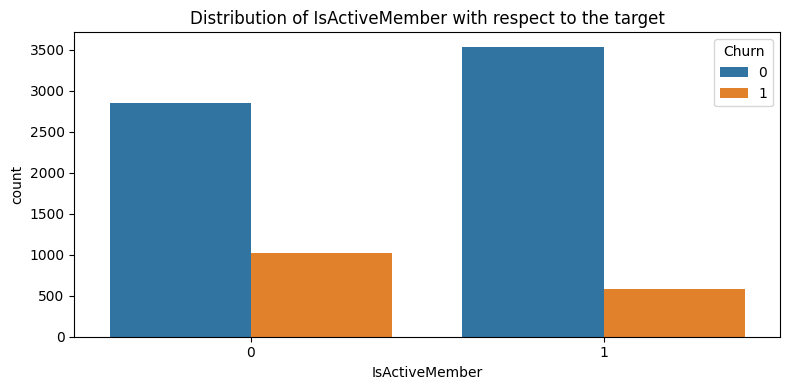

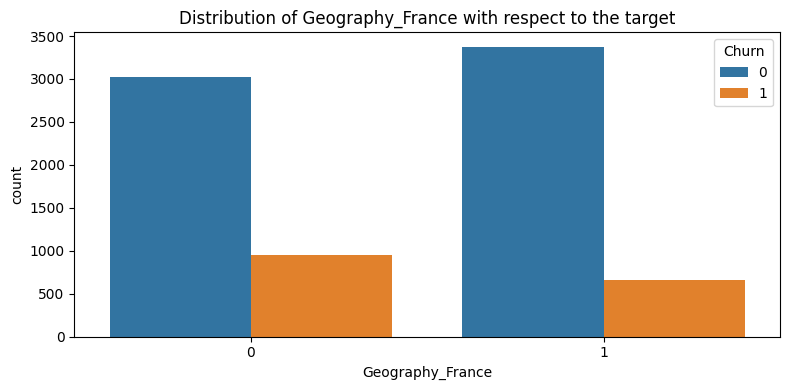

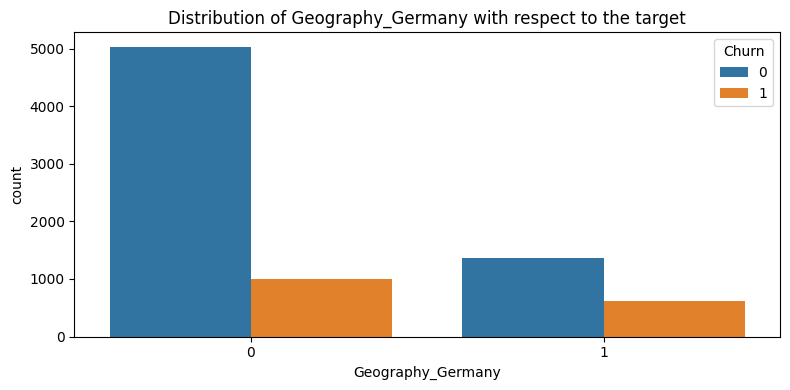

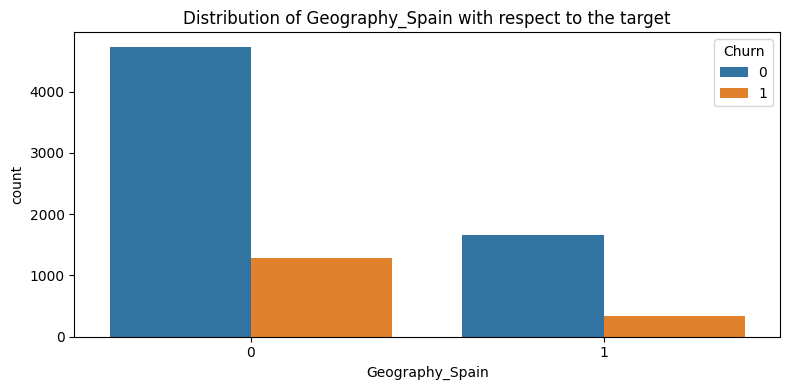

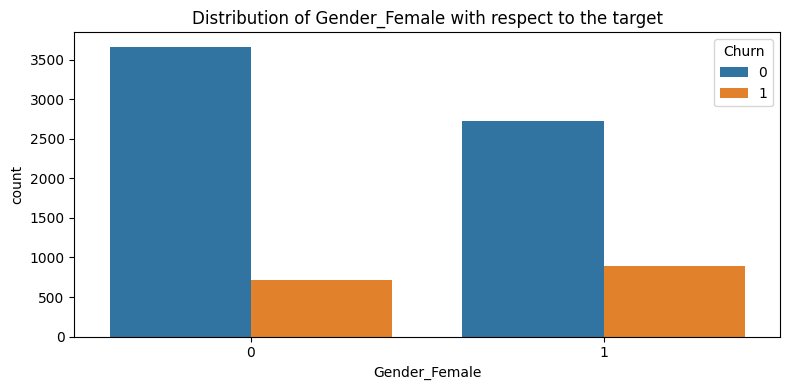

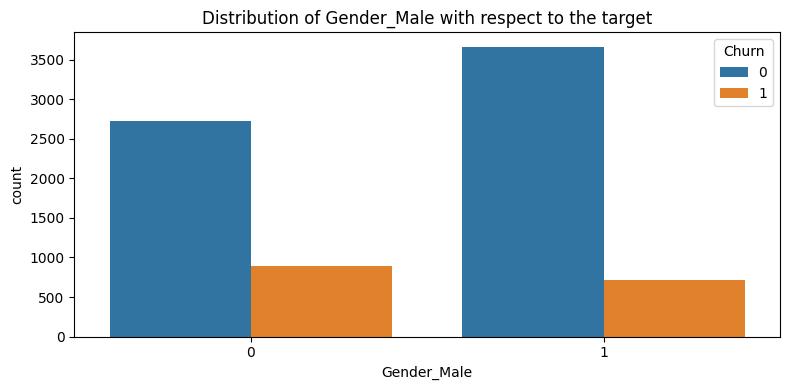

In [8]:
#Plotting distributions for numerical features
for col in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=Y, y=X[col])
    plt.title(f"Distribution of {col} with respect to the target")
    plt.xlabel("Target (Y)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.histplot(data=X, x=col, hue=Y, kde=True, element="step")
    plt.title(f"Istogram of {col}")
    plt.tight_layout()
    plt.show()

#Plotting distributions for categorical features
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=X[col], hue=Y)
    plt.title(f"Distribution of {col} with respect to the target")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


Feature: CreditScore
Shapiro-Wilk: stat=0.9939, p-value=0.0000
Kolmogorov-Smirnov: stat=0.0197, p-value=0.0039
D’Agostino-Pearson: stat=99.8931, p-value=0.0000
Anderson-Darling: statistic=4.2071
Critical values: [0.576 0.656 0.787 0.918 1.091]
Significance levels: [15.  10.   5.   2.5  1. ]


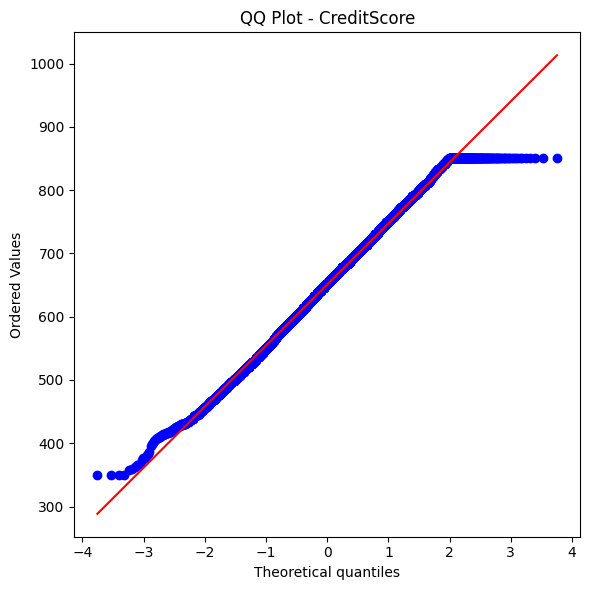

Feature: Age
Shapiro-Wilk: stat=0.9438, p-value=0.0000
Kolmogorov-Smirnov: stat=0.0998, p-value=0.0000
D’Agostino-Pearson: stat=1210.6503, p-value=0.0000
Anderson-Darling: statistic=112.9215
Critical values: [0.576 0.656 0.787 0.918 1.091]
Significance levels: [15.  10.   5.   2.5  1. ]


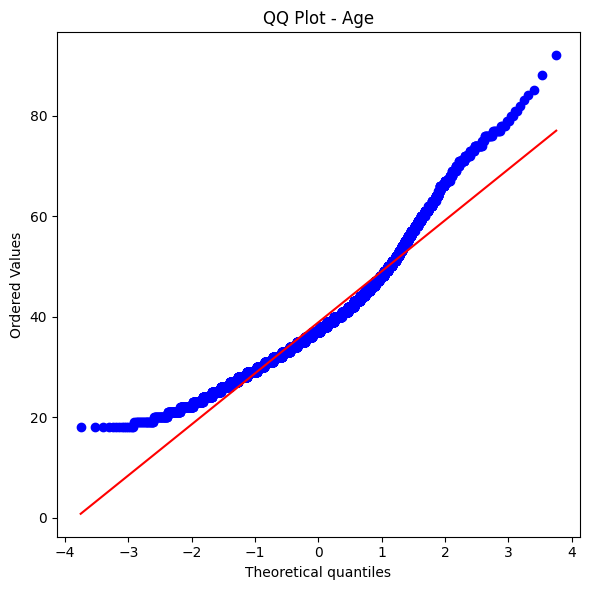

Feature: Tenure
Shapiro-Wilk: stat=0.9485, p-value=0.0000
Kolmogorov-Smirnov: stat=0.1067, p-value=0.0000
D’Agostino-Pearson: stat=5171.1875, p-value=0.0000
Anderson-Darling: statistic=120.7094
Critical values: [0.576 0.656 0.787 0.918 1.091]
Significance levels: [15.  10.   5.   2.5  1. ]


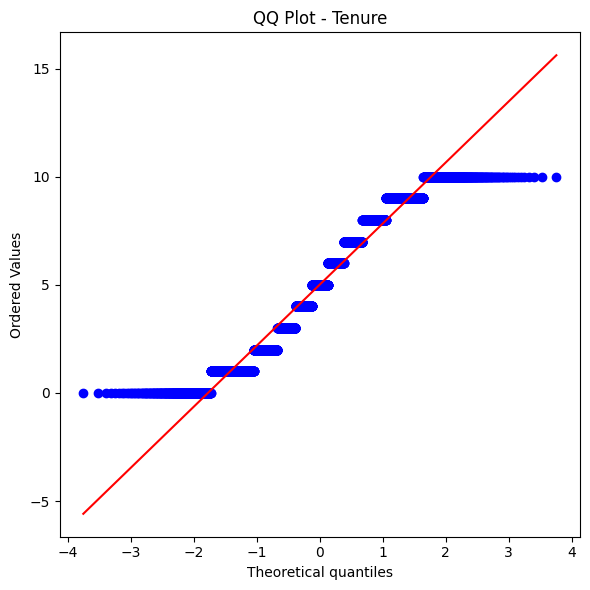

Feature: Balance
Shapiro-Wilk: stat=0.8442, p-value=0.0000
Kolmogorov-Smirnov: stat=0.2534, p-value=0.0000
D’Agostino-Pearson: stat=49143.5678, p-value=0.0000
Anderson-Darling: statistic=526.5564
Critical values: [0.576 0.656 0.787 0.918 1.091]
Significance levels: [15.  10.   5.   2.5  1. ]


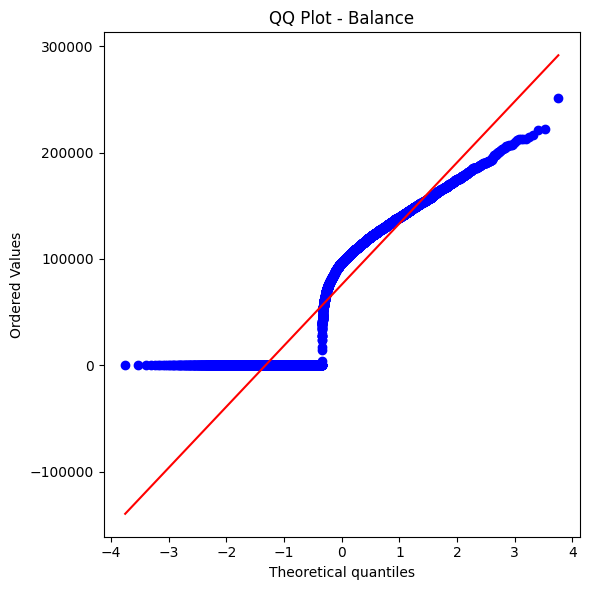

Feature: NumOfProducts
Shapiro-Wilk: stat=0.7080, p-value=0.0000
Kolmogorov-Smirnov: stat=0.3259, p-value=0.0000
D’Agostino-Pearson: stat=658.8955, p-value=0.0000
Anderson-Darling: statistic=1068.6283
Critical values: [0.576 0.656 0.787 0.918 1.091]
Significance levels: [15.  10.   5.   2.5  1. ]


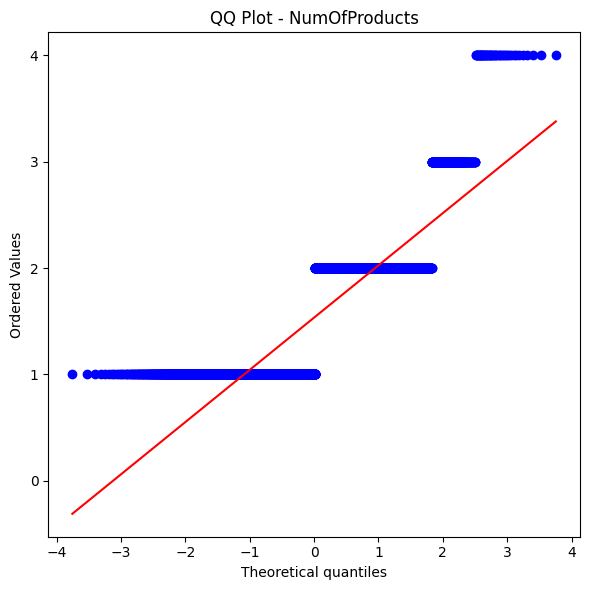

Feature: Salary
Shapiro-Wilk: stat=0.9576, p-value=0.0000
Kolmogorov-Smirnov: stat=0.0556, p-value=0.0000
D’Agostino-Pearson: stat=5551.0782, p-value=0.0000
Anderson-Darling: statistic=81.5126
Critical values: [0.576 0.656 0.787 0.918 1.091]
Significance levels: [15.  10.   5.   2.5  1. ]


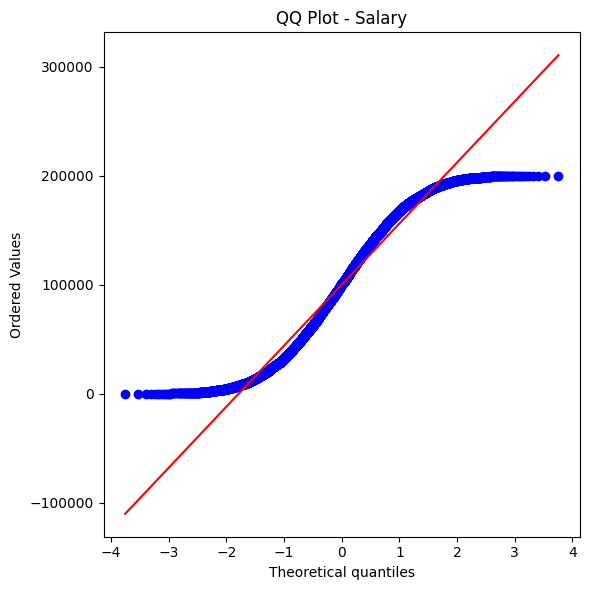

In [9]:
results = {}

#We compute a set of statistical tests to investigate if the numerical features are normally distributed
for col in numerical_features:
    data = X[col].dropna()

    print(f"Feature: {col}")

    #Shapiro-Wilk Test
    shapiro_stat, shapiro_p = stats.shapiro(data)
    print(f"Shapiro-Wilk: stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

    #Kolmogorov-Smirnov Test
    ks_stat, ks_p = stats.kstest(
        (data - data.mean()) / data.std(),
        'norm')
    print(f"Kolmogorov-Smirnov: stat={ks_stat:.4f}, p-value={ks_p:.4f}")

    #D’Agostino & Pearson normality Test
    dag_stat, dag_p = stats.normaltest(data)
    print(f"D’Agostino-Pearson: stat={dag_stat:.4f}, p-value={dag_p:.4f}")

    #Anderson-Darling Test
    ad_result = stats.anderson(data, dist='norm')
    print(f"Anderson-Darling: statistic={ad_result.statistic:.4f}")
    print(f"Critical values: {ad_result.critical_values}")
    print(f"Significance levels: {ad_result.significance_level}")

    #QQ Plot
    plt.figure(figsize=(6, 6))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"QQ Plot - {col}")
    plt.tight_layout()
    plt.show()

In [10]:
#Homoschedasticity test
def box_m_test_binary(X, y, alpha=0.05, class_labels=(0, 1)):
    """
    Run Box's M test for equality of covariance matrices between two classes.
    """

    print(" Box's M Test for Homoscedasticity")


    y = np.asarray(y)

    if isinstance(X, pd.DataFrame):
        X_df = X.copy()
    else:
        X_df = pd.DataFrame(X)

    X_df["target"] = y

    c0, c1 = class_labels

    if not set(class_labels).issubset(set(X_df["target"].unique())):
        raise ValueError(f"Expected classes {class_labels} in y, "
                         f"but found {X_df['target'].unique()}")

    data_c0 = X_df[X_df["target"] == c0].drop(columns=["target"]).values
    data_c1 = X_df[X_df["target"] == c1].drop(columns=["target"]).values


    cov_0 = np.cov(data_c0, rowvar=False)
    cov_1 = np.cov(data_c1, rowvar=False)

    nobs_0 = data_c0.shape[0]
    nobs_1 = data_c1.shape[0]

    cov_list = [cov_0, cov_1]
    nobs_list = [nobs_0, nobs_1]


    box_m_result = test_cov_oneway(cov_list, nobs_list)

    chi2_stat = box_m_result.statistic_chi2
    df = box_m_result.df_chi2
    p_value = box_m_result.pvalue_chi2

    print()
    print(f"Number of features (p):         {cov_0.shape[0]}")
    print(f"Class {c0} observations (n1):   {nobs_0}")
    print(f"Class {c1} observations (n2):   {nobs_1}")
    print("-" * 60)
    print(f"Box's M Statistic (Chi2 approx.): {chi2_stat:.4f}")
    print(f"Degrees of Freedom (df):          {df:.0f}")
    print(f"P-value (Chi2 approx.):           {p_value:.10e}")
    print("-" * 60)

    if p_value < alpha:
        conclusion = (
            f"p-value ({p_value:.3e}) < alpha ({alpha}). "
            "Reject H0: covariance matrices are equal.\n"
            "→ Homoscedasticity assumption for LDA is NOT supported.\n"
        )
    else:
        conclusion = (
            f"p-value ({p_value:.3e}) >= alpha ({alpha}). "
            "Fail to reject H0: covariance matrices are equal.\n"
        )

    print(conclusion)

    return {
        "chi2_stat": chi2_stat,
        "df": df,
        "p_value": p_value,
        "alpha": alpha,
        "nobs_class0": nobs_0,
        "nobs_class1": nobs_1,
        "conclusion": conclusion,
    }



box_m_result = box_m_test_binary(X,Y,
                                 alpha=0.05,
                                  class_labels=(0, 1))


 Box's M Test for Homoscedasticity

Number of features (p):         13
Class 0 observations (n1):   6391
Class 1 observations (n2):   1609
------------------------------------------------------------
Box's M Statistic (Chi2 approx.): inf
Degrees of Freedom (df):          91
P-value (Chi2 approx.):           0.0000000000e+00
------------------------------------------------------------
p-value (0.000e+00) < alpha (0.05). Reject H0: covariance matrices are equal.
→ Homoscedasticity assumption for LDA is NOT supported.



## Chapter 3 – Anomaly Detection


In [11]:
#Creating training and testing subsets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    stratify=Y,
    random_state=5)

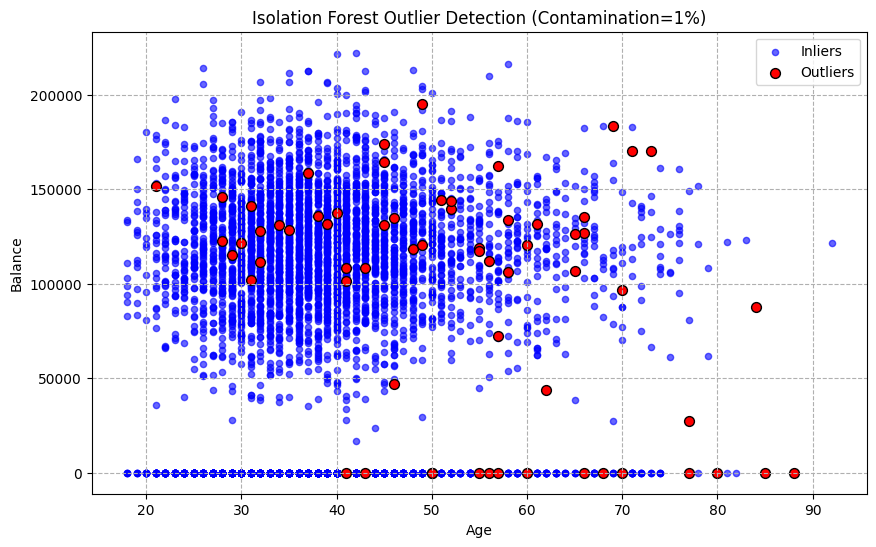

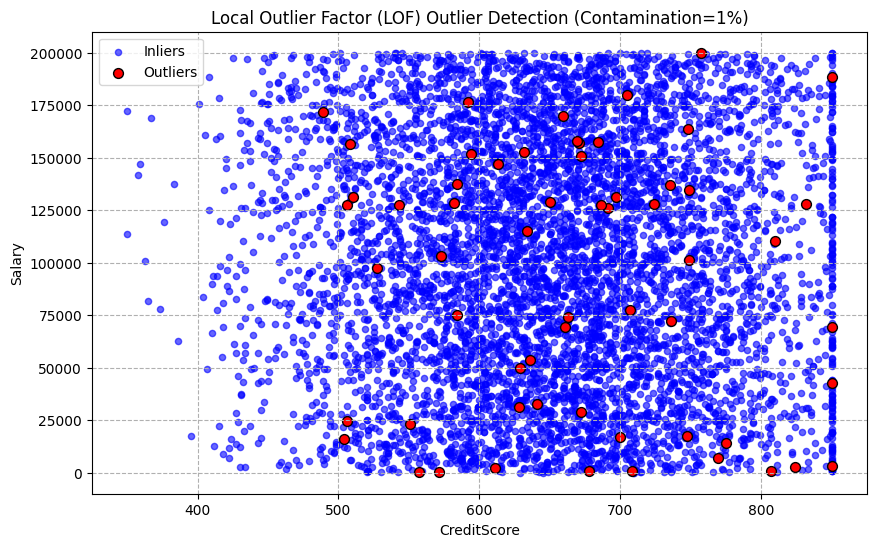

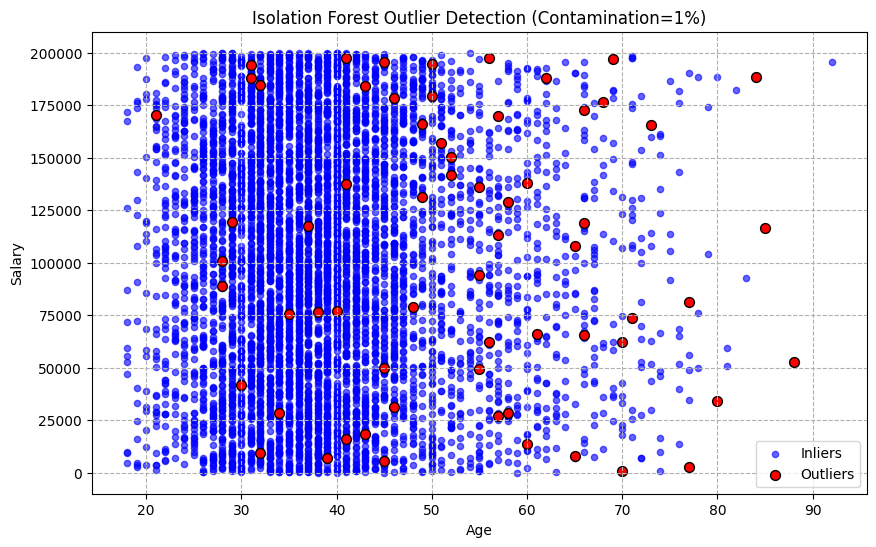

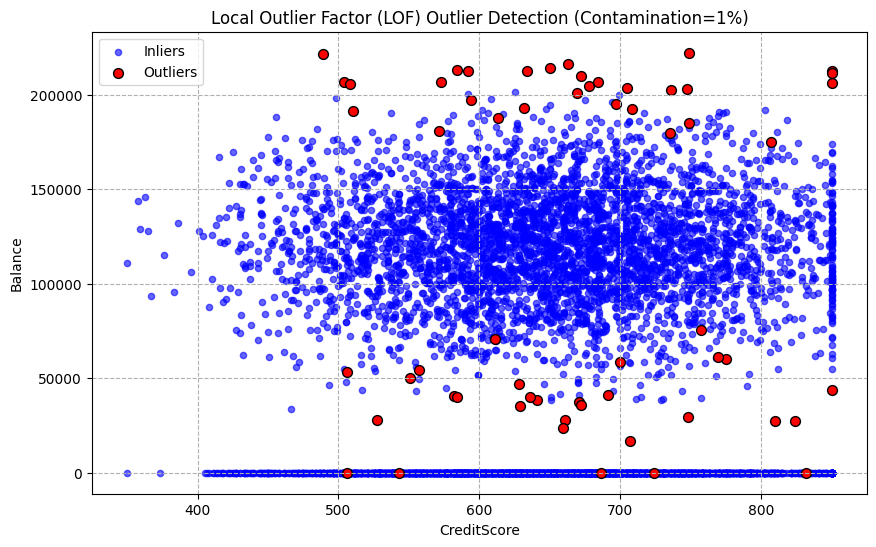

In [12]:
contamination_rate = 0.01
feature_subset_for_outliers = X_train[numerical_features]

# Fit anomaly models on TRAIN ONLY
isf = IsolationForest(
    contamination=contamination_rate,
    random_state=5,
    n_estimators=100
)

isf.fit(feature_subset_for_outliers)

X_train['ISF_Outlier_Flag'] = isf.predict(feature_subset_for_outliers)
# Scores: the higher the score, the less anomalous the point is.
X_train['ISF_Anomaly_Score'] = isf.decision_function(feature_subset_for_outliers)

isf_flag_test= isf.predict(X_test[numerical_features])
X_test['ISF_Outlier_Flag'] = isf_flag_test
X_test['ISF_Anomaly_Score'] = isf.decision_function(X_test[numerical_features])

lof = LocalOutlierFactor(
    contamination=contamination_rate,
    novelty=True
)

lof.fit(feature_subset_for_outliers)

lof_flag_train = lof.predict(feature_subset_for_outliers)
X_train['LOF_Outlier_Flag'] = lof_flag_train
X_train['LOF_Anomaly_Score'] = lof.negative_outlier_factor_ * -1

lof_flag_test = lof.predict(X_test[numerical_features])
X_test['LOF_Outlier_Flag'] = lof_flag_test
scores_test = lof.score_samples(X_test[numerical_features])
X_test['LOF_Anomaly_Score'] = -scores_test

# Create a plotting dataframe using pair of features for visualization clarity
plot_data = pd.DataFrame({
    'Age': X_train['Age'],
    'Balance': X_train['Balance'],
    'CreditScore': X_train['CreditScore'],
    'Salary': X_train['Salary'],
    'ISF_Flag': X_train['ISF_Outlier_Flag'],
    'LOF_Flag': X_train['LOF_Outlier_Flag']
})

#Creating function to plot anomalies for pairs of features
def create_outlier_plot(df, flag_col, title, filename, feature_one, feature_two):
    """Generates a scatter plot to visualize outliers."""
    plt.figure(figsize=(10, 6))

    # Plot Inliers (Flag 1)
    inliers = df[df[flag_col] == 1]
    plt.scatter(inliers[feature_one], inliers[feature_two], label='Inliers', c='blue', alpha=0.6, s=20)

    # Plot Outliers (Flag -1)
    outliers = df[df[flag_col] == -1]
    plt.scatter(outliers[feature_one], outliers[feature_two], label='Outliers', c='red', s=50, edgecolors='k')

    plt.title(f'{title} (Contamination={contamination_rate*100:.0f}%)')
    plt.xlabel(feature_one)
    plt.ylabel(feature_two)
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.savefig(filename)
    plt.show()


    # Generate plots

create_outlier_plot(plot_data, 'ISF_Flag', 'Isolation Forest Outlier Detection', 'isolation_forest_outliers_final.png','Age', 'Balance')
create_outlier_plot(plot_data, 'LOF_Flag', 'Local Outlier Factor (LOF) Outlier Detection', 'lof_outliers_final.png','CreditScore', 'Salary')
create_outlier_plot(plot_data, 'ISF_Flag', 'Isolation Forest Outlier Detection', 'isolation_forest_outliers_final.png','Age', 'Salary')
create_outlier_plot(plot_data, 'LOF_Flag', 'Local Outlier Factor (LOF) Outlier Detection', 'lof_outliers_final.png','CreditScore', 'Balance')

In [13]:
#Dataset with Anomaly Scores added as a feature
X_train_aug = X_train.drop(columns=['ISF_Outlier_Flag', 'LOF_Outlier_Flag'])
X_test_aug = X_test.drop(columns=['ISF_Outlier_Flag', 'LOF_Outlier_Flag'])

In [14]:
#New feature names
features_to_scale = numerical_features + ['ISF_Anomaly_Score', 'LOF_Anomaly_Score']

#Performing z-score scaling
X_mean = X_train_aug[features_to_scale].mean()
X_std  = X_train_aug[features_to_scale].std()

X_train_aug[features_to_scale] = (X_train_aug[features_to_scale] - X_mean) / X_std
X_test_aug[features_to_scale]  = (X_test_aug[features_to_scale]  - X_mean) / X_std


## Chapter 4 – Feature Engineering & Data Manipulation


In [15]:
#Since the dataset is unbalanced we perform a rebalancing creating synthetic datas using Bordeline SMOTE technique

#Initializing Borderline SMOTE, seed for reproducibility
sm = BorderlineSMOTE(random_state=5)

#Applying Borderline SMOTE only on Training set
X_res, Y_res = sm.fit_resample(X_train_aug, Y_train)

#Verifiy if it's balanced
print(f"Original dataset: {Counter(Y_train)}")
print(f"Balanced dataset (SMOTE): {Counter(Y_res)}")

names = X_res.columns

Original dataset: Counter({0: 5113, 1: 1287})
Balanced dataset (SMOTE): Counter({1: 5113, 0: 5113})


## Chapter 5 – Statistical Learning Approach

In [16]:
#Defining function to plot the confusion matrix
def plot_conf_matrix(y_true, y_pred, class_names=None, normalize=False, title="Confusion Matrix"):

    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    else:
        fmt = "d"

    # #If class_names is false
    if class_names is None:
        #ordere classe
        labels = np.unique(np.concatenate([y_true, y_pred]))
        class_names = labels

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

### 5.1 Gaussian Naive Bayes Classifier

Best Parameter: {'var_smoothing': np.float64(1e-07)}
Best accuracy CV: 0.7837075472670659
Accuracy: 0.714375
Precision: 0.3923444976076555
Sensitivity (Recall): 0.7639751552795031
F1-score: 0.5184404636459431


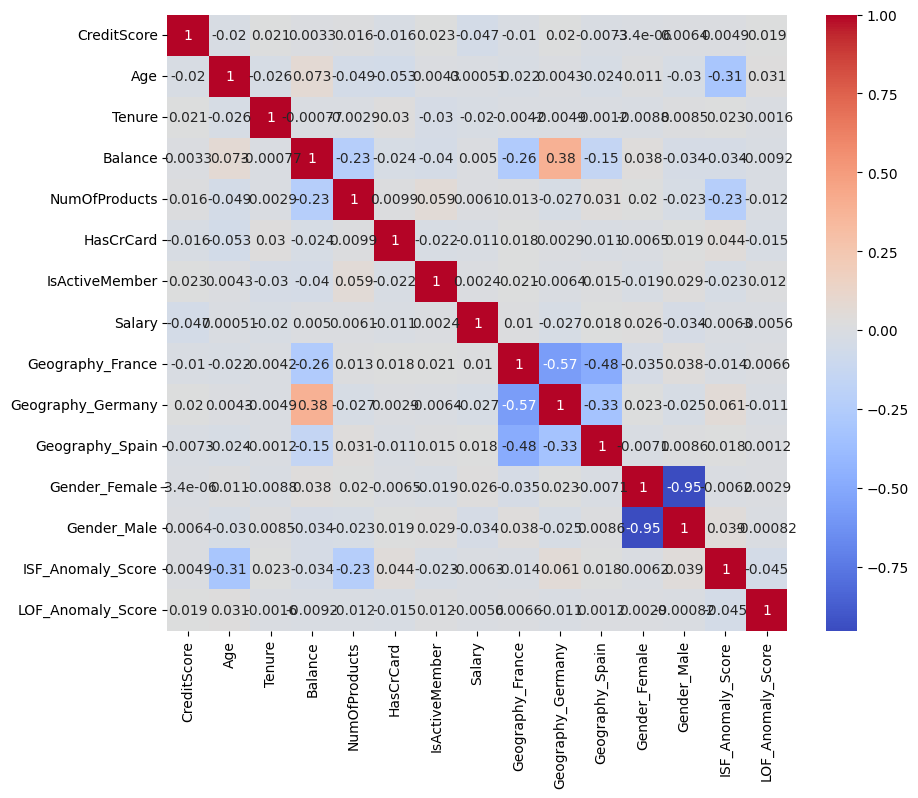

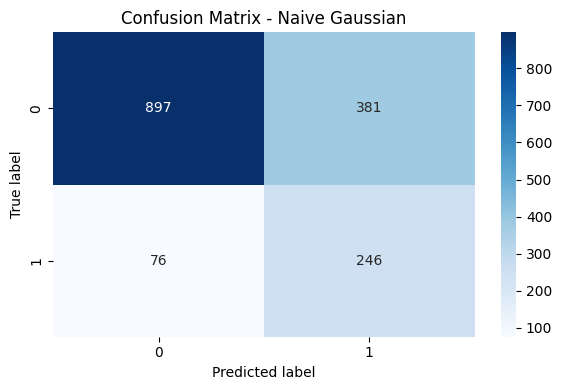

In [20]:
#Fitting of the first basic statistical learner
nb = GaussianNB()

param_grid = {
    'var_smoothing': np.logspace(-12, -6, 7)
}

grid = GridSearchCV(
    estimator=nb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_res, Y_res)


best_nb = grid.best_estimator_
print("Best Parameter:", grid.best_params_)
print("Best accuracy CV:", grid.best_score_)

Y_pred_NB = best_nb.predict(X_test_aug)

#Metrics
print("Accuracy:",metrics.accuracy_score(Y_test, Y_pred_NB))
print("Precision:",metrics.precision_score(Y_test, Y_pred_NB))
print("Sensitivity (Recall):",metrics.recall_score(Y_test, Y_pred_NB))
print("F1-score:",    metrics.f1_score(Y_test, Y_pred_NB))

#Correlation matrix for all the features
corr_matrix = X_res.corr()

#Plotting correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.savefig('CorrelationMatrix.png')
plt.show()

#Plotting confusion matrix
class_names = best_nb.classes_
plot_conf_matrix(Y_test, Y_pred_NB, class_names=class_names,
                 normalize=False,
                 title="Confusion Matrix - Naive Gaussian")


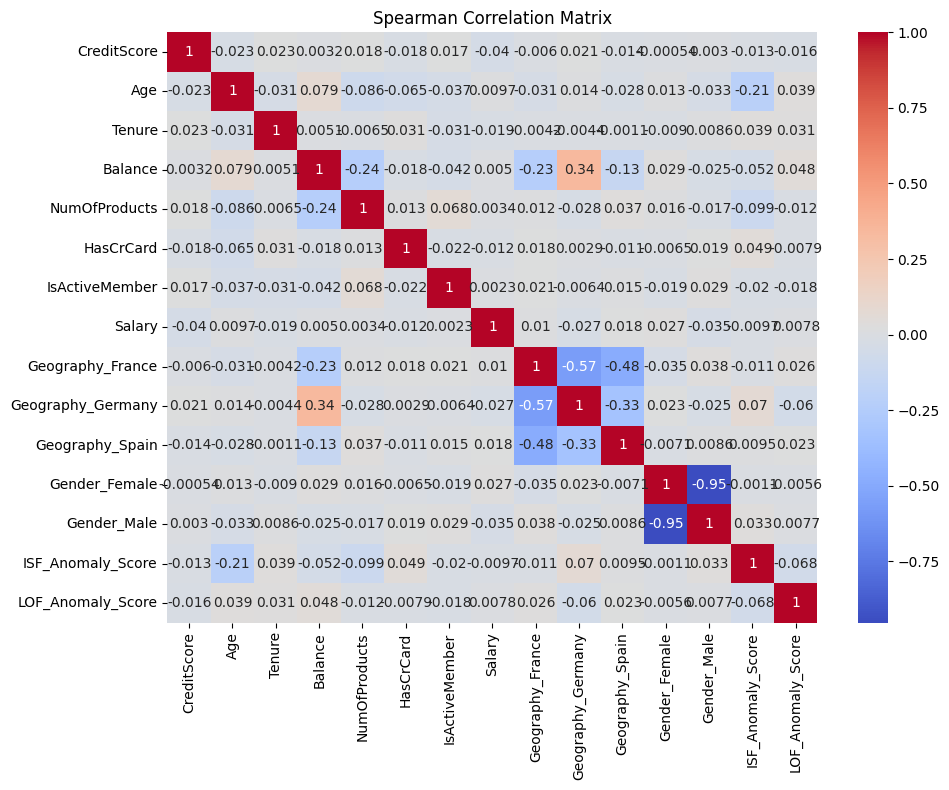

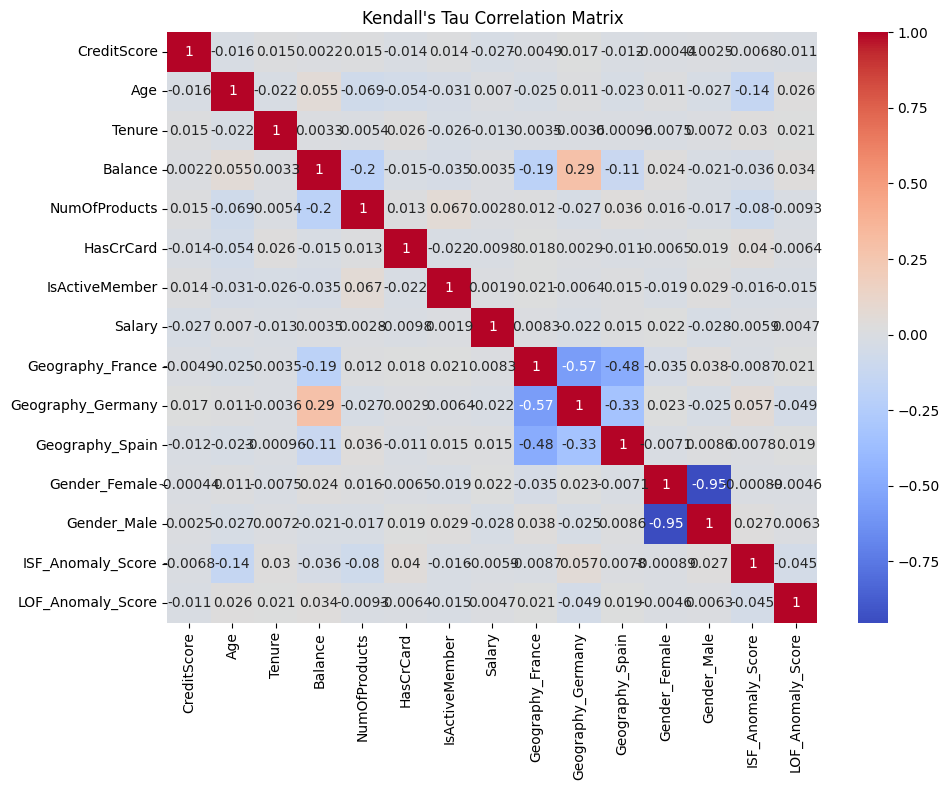

In [21]:
# Also compute Kendall’s tau and Spearman correlation matrices to complement
# the standard Pearson correlation and capture potential non-linear/ordinal relationships.

# Spearman
spearman_corr = X_res.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm')
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.savefig('CorrelationMatrix_Spearman.png')
plt.show()

# Kendall’s tau
kendall_corr = X_res.corr(method='kendall')

plt.figure(figsize=(10, 8))
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm')
plt.title("Kendall's Tau Correlation Matrix")
plt.tight_layout()
plt.savefig('CorrelationMatrix_Kendall.png')
plt.show()

### 5.2 Linear Discriminant Analysis

LDA Accuracy: 0.745
LDA Precision: 0.41330645161290325
LDA Sensitivity (Recall): 0.6366459627329193
F1-score: 0.5012224938875306


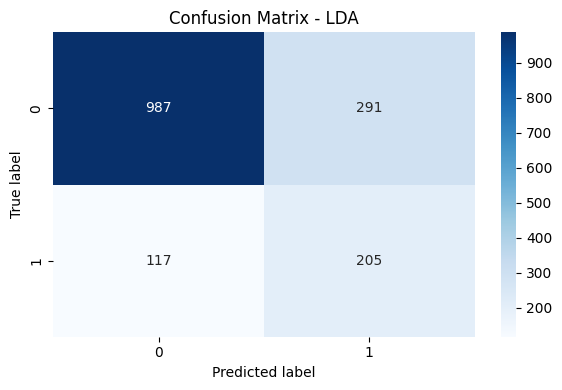

In [22]:
num_cols = ['Balance', 'CreditScore']

#Yeo-Johnson transformation
preprocess = ColumnTransformer(
    transformers=[
        ('yeojohnson', PowerTransformer(method='yeo-johnson', standardize=True),
         num_cols)
    ],
    remainder='passthrough'
)

lda_trasform = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LDA())
])

lda_trasform.fit(X_res, Y_res)
y_pred_lda_trasform = lda_trasform.predict(X_test_aug)

#Metrics
print("LDA Accuracy:", metrics.accuracy_score(Y_test, y_pred_lda_trasform))
print("LDA Precision:", metrics.precision_score(Y_test, y_pred_lda_trasform))
print("LDA Sensitivity (Recall):", metrics.recall_score(Y_test, y_pred_lda_trasform))
print("F1-score:",    metrics.f1_score(Y_test, y_pred_lda_trasform))

#Plottig confusion matrix
class_names = lda_trasform.classes_
plot_conf_matrix(Y_test, y_pred_lda_trasform, class_names=class_names,
                 normalize=False,
                 title="Confusion Matrix - LDA")


### 5.3 Quadratic Discriminant Analysis

LDA Accuracy: 0.7525
LDA Precision: 0.4332129963898917
LDA Sensitivity (Recall): 0.7453416149068323
F1-score: 0.547945205479452


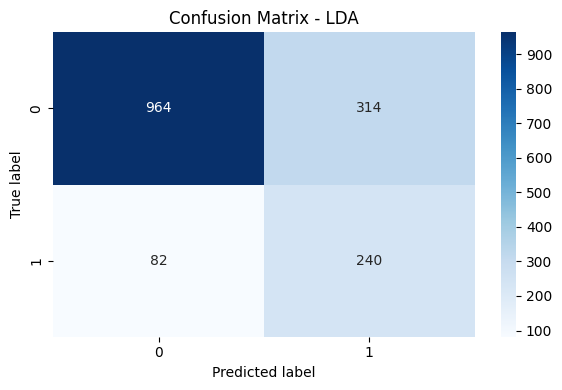

In [23]:
num_cols = ['Balance', 'CreditScore']

#Yeo-Johnson transformation
preprocess = ColumnTransformer(
    transformers=[
        ('yeojohnson', PowerTransformer(method='yeo-johnson', standardize=True),
         num_cols)
    ],
    remainder='passthrough'
)

qda_trasform = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', QDA(reg_param=0.1))
])

qda_trasform.fit(X_res, Y_res)
y_pred_qda_trasform = qda_trasform.predict(X_test_aug)

#Metrics
print("LDA Accuracy:", metrics.accuracy_score(Y_test, y_pred_qda_trasform))
print("LDA Precision:", metrics.precision_score(Y_test, y_pred_qda_trasform))
print("LDA Sensitivity (Recall):", metrics.recall_score(Y_test, y_pred_qda_trasform))
print("F1-score:",    metrics.f1_score(Y_test, y_pred_qda_trasform))

#Plottig confusion matrix
class_names = qda_trasform.classes_
plot_conf_matrix(Y_test, y_pred_qda_trasform, class_names=class_names,
                 normalize=False,
                 title="Confusion Matrix - LDA")

### 5.4 Logistic Regression

Best threshold (Youden): 0.4780842992899424
Max Youden's Index: 0.4203919167176975
Metrics with Youden-optimal threshold

Accuracy: 0.731875
Precision: 0.4011090573012939
Sensitivity (Recall): 0.6739130434782609
Specificity: 0.7464788732394366
Youden's Index: 0.4203919167176975
F1-score: 0.5028968713789108


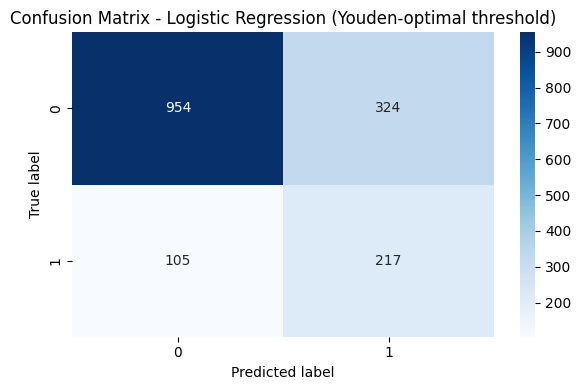

In [24]:
#Fitting the model
lr = LogisticRegression(penalty='l2', C=0.5, solver='lbfgs')
lrfit = lr.fit(X_res, Y_res)

# Probabilities for the positive class
y_scores = lrfit.predict_proba(X_test_aug)[:, 1]
pos_label = lr.classes_[1]
neg_label = lr.classes_[0]

fpr, tpr, thresholds = roc_curve(Y_test, y_scores, pos_label=pos_label)

# Youden's Index J for selecting the optimal threshold
youden_J = tpr - fpr
best_idx = np.argmax(youden_J)
best_threshold = thresholds[best_idx]

print("Best threshold (Youden):", best_threshold)
print("Max Youden's Index:", youden_J[best_idx])
# Apply optimal threshold
Y_pred_opt = np.where(y_scores >= best_threshold, pos_label, neg_label)

# Metrics with optimal threshold
accuracy_opt = metrics.accuracy_score(Y_test, Y_pred_opt)
precision_opt = metrics.precision_score(Y_test, Y_pred_opt, pos_label=pos_label)
sensitivity_opt = metrics.recall_score(Y_test, Y_pred_opt, pos_label=pos_label)

cm_opt = confusion_matrix(Y_test, Y_pred_opt, labels=[neg_label, pos_label])
tn, fp, fn, tp = cm_opt.ravel()
specificity_opt = tn / (tn + fp)
youden_opt = sensitivity_opt + specificity_opt - 1

print("Metrics with Youden-optimal threshold\n")
print("Accuracy:", accuracy_opt)
print("Precision:", precision_opt)
print("Sensitivity (Recall):", sensitivity_opt)
print("Specificity:", specificity_opt)
print("Youden's Index:", youden_opt)
print("F1-score:", metrics.f1_score(Y_test, Y_pred_opt, pos_label=pos_label))

# Confusion matrix with optimal threshold
class_names = lr.classes_
plot_conf_matrix(
    Y_test,
    Y_pred_opt,
    class_names=class_names,
    normalize=False,
    title="Confusion Matrix - Logistic Regression (Youden-optimal threshold)"
)


## Chapter 6 –Machine Learning Approach

In [25]:
#Hyperparameter tuning function using StratifiedKFold and Gridsearch
#This function will be used to train all the different ML models

def hyperparameter_tuning(model, param_grid, X_train, Y_train, X_test, Y_test):

  #Classifier
  clf = model(random_state=5)

  #Type of k-fold used in the grid search
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

  #Grid search
  grid_search = GridSearchCV(
      estimator=clf,
      param_grid=param_grid,
      scoring='roc_auc',
      cv=cv,
      n_jobs=-1,
      verbose=0
  )

  grid_search.fit(X_train, Y_train)

  #Best model
  best_model = grid_search.best_estimator_
  best_score = grid_search.best_score_

  #Probabilities on test set
  Y_prob_test = best_model.predict_proba(X_test)[:, 1]

  #ROC Curve on test set
  fpr, tpr, thresholds = roc_curve(Y_test, Y_prob_test)
  roc_auc = auc(fpr, tpr)

  # Plotting ROC Curve
  plt.figure()
  plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
  plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.legend(loc='lower right')
  plt.show()

  #Metrics
  print(f"Best hyperparameters CV: {grid_search.best_params_}")
  print("\n")
  print(f"Best AUC Score (Mean Cross-Validation): {best_score:.4f}")
  print(f"Final AUC Score (Test Set): {roc_auc:.4f}")

  best_idx = grid_search.best_index_
  std_best = grid_search.cv_results_['std_test_score'][best_idx]

  cv_results = grid_search.cv_results_
  best_idx = grid_search.best_index_

  n_splits = cv.get_n_splits()
  fold_scores = [
      cv_results[f'split{i}_test_score'][best_idx]
      for i in range(n_splits)
  ]

  plt.figure()
  plt.boxplot(fold_scores)
  plt.ylabel('AUC (ROC)')
  plt.title('Distribution of AUC for the best model (CV)')
  plt.grid(axis='y', linestyle='--', alpha=0.5)
  plt.show()

  #Metrics for the optimal model found
  distances = np.sqrt((1 - tpr)**2 + (fpr)**2)
  optimal_idx = np.argmin(distances)
  optimal_threshold = thresholds[optimal_idx]

  Y_pred_optimal = (Y_prob_test >= optimal_threshold).astype(int)

  accuracy = metrics.accuracy_score(Y_test, Y_pred_optimal)
  precision = metrics.precision_score(Y_test, Y_pred_optimal)
  recall = metrics.recall_score(Y_test, Y_pred_optimal)

  print(f'Optimal threshold: {optimal_threshold}')
  print(f'Accuracy: {accuracy}')
  print(f'Precision: {precision}')
  print(f'Sensitivity (Recall): {recall}')

  #Confusion matrix
  class_names = best_model.classes_
  plot_conf_matrix(Y_test, Y_pred_optimal, class_names=class_names,
                  normalize=False,
                  title=f"Confusion Matrix - " + str(model))

  return best_model, best_score, Y_pred_optimal



### 6.1 Decision Tree Classifier

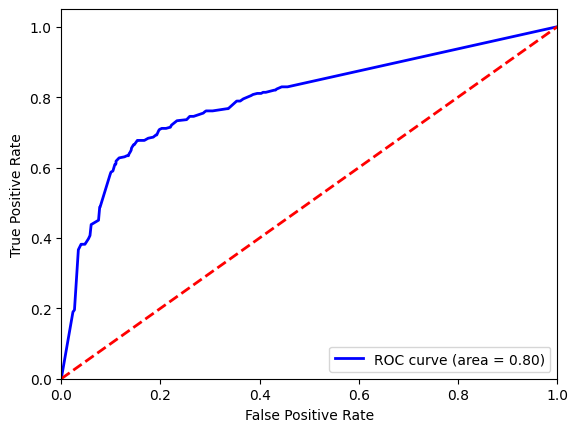

Best hyperparameters CV: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}


Best AUC Score (Mean Cross-Validation): 0.8865
Final AUC Score (Test Set): 0.7960


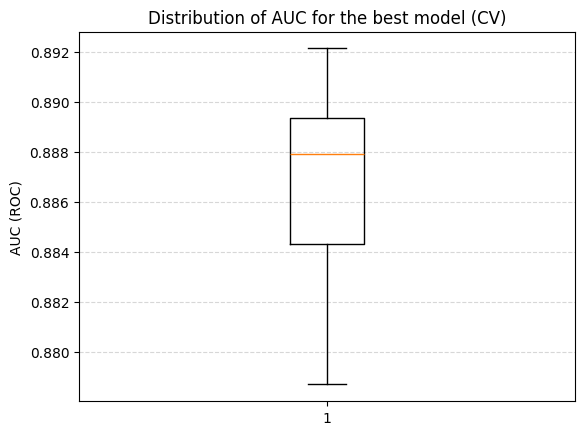

Optimal threshold: 0.4375
Accuracy: 0.783125
Precision: 0.47401247401247404
Sensitivity (Recall): 0.7080745341614907


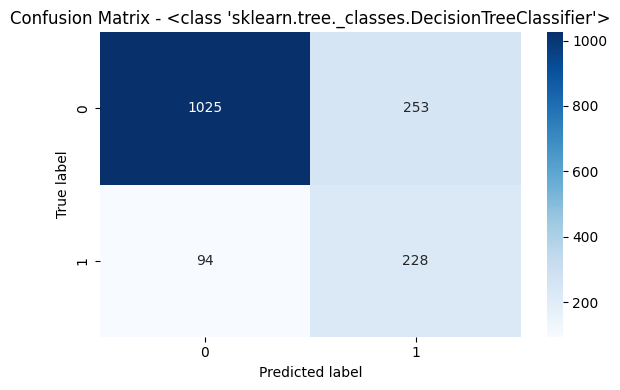

In [26]:
#Hyperparameter grid for tuning
param_grid_CT = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5,],
    'min_samples_leaf': [1, 2, 5]
}

best_model_CT, best_score_CT, Y_pred_CT = hyperparameter_tuning(DecisionTreeClassifier, param_grid_CT, X_res, Y_res, X_test_aug, Y_test)

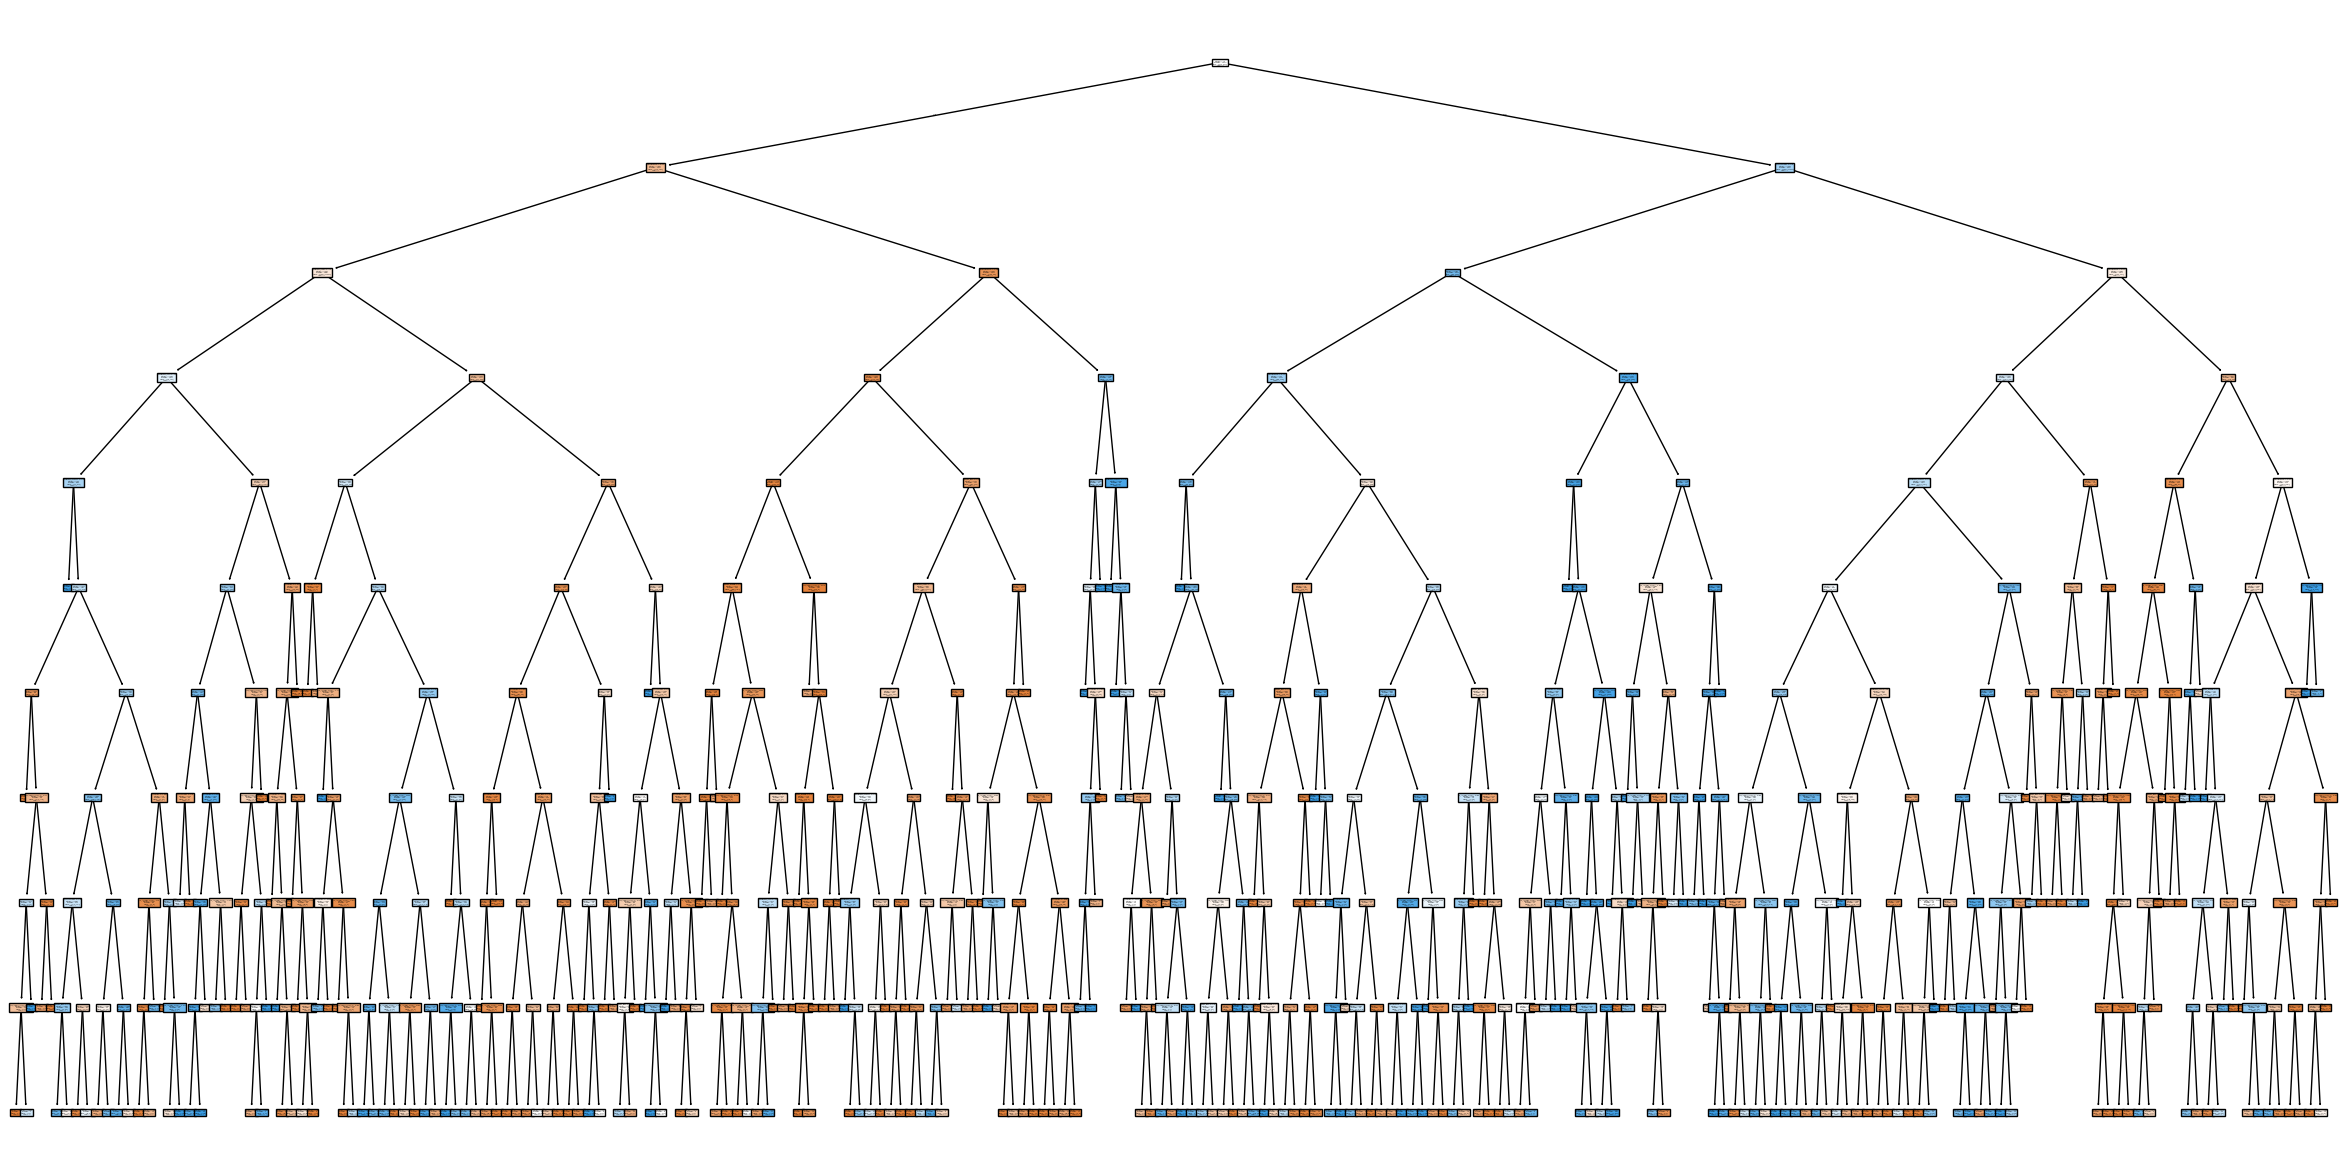

In [27]:
#Plotting the actual tree
plt.figure(figsize=(30,15))
tree.plot_tree(best_model_CT, filled=True, feature_names=names, class_names=['0', '1'])
plt.show()

### 6.2 Bagging

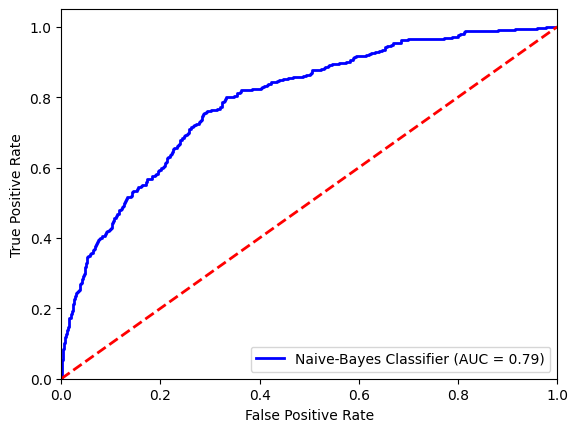

Optimal threshold: 0.5057764485790928
Accuracy: 0.72125
Precision: 0.3983606557377049
Sensitivity (Recall): 0.7546583850931677


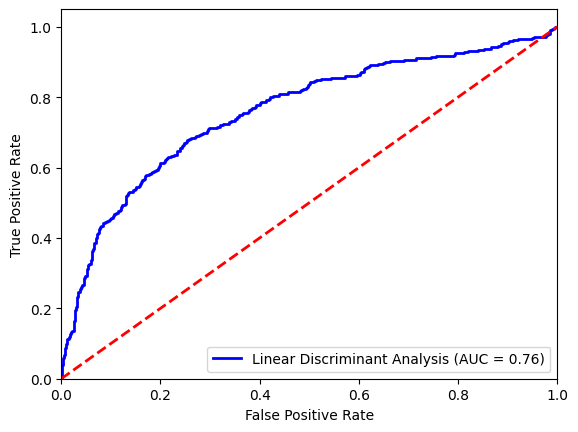

Optimal threshold: 0.4754444287891149
Accuracy: 0.733125
Precision: 0.4029574861367837
Sensitivity (Recall): 0.6770186335403726


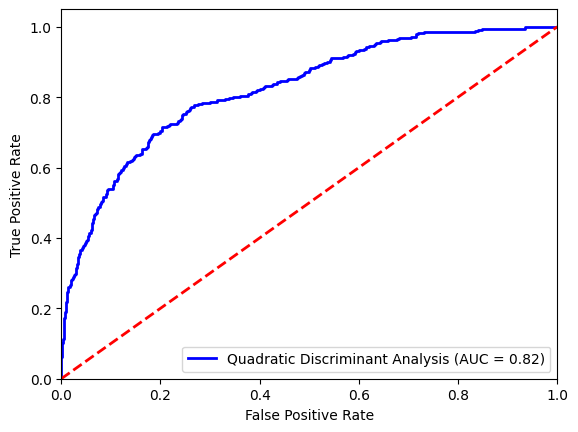

Optimal threshold: 0.4725042716260292
Accuracy: 0.745625
Precision: 0.42710120068610635
Sensitivity (Recall): 0.7732919254658385


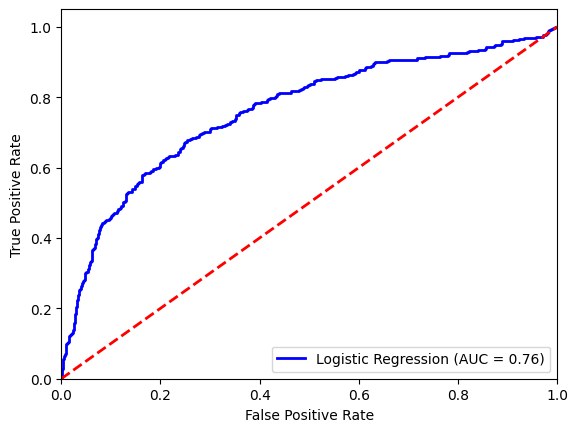

Optimal threshold: 0.4791960826281094
Accuracy: 0.735625
Precision: 0.405607476635514
Sensitivity (Recall): 0.6739130434782609


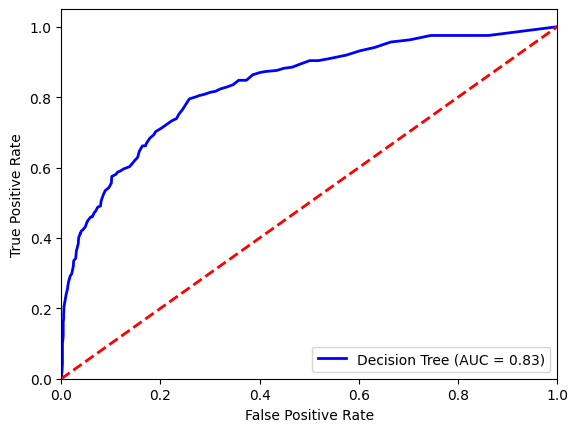

Optimal threshold: 0.29
Accuracy: 0.7525
Precision: 0.43686006825938567
Sensitivity (Recall): 0.7950310559006211


In [28]:
#We implement a bagging strategy for each of the "basic" learner we have tested so far

#Choice of models
estimators = {
    'Naive-Bayes Classifier': GaussianNB(),
    'Linear Discriminant Analysis': LDA(),
    'Quadratic Discriminant Analysis': QDA(reg_param=0.1),
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree': DecisionTreeClassifier()
}

#Cycle for bagging
for name, estimator in estimators.items():
    bagging_model = BaggingClassifier(
        estimator=estimator,
        n_estimators=100,
        random_state=42
    )
    bagging_model.fit(X_res, Y_res)
    Y_prob_test = bagging_model.predict_proba(X_test_aug)[:, 1]
    fpr, tpr, thresholds = roc_curve(Y_test, Y_prob_test)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

    distances = np.sqrt((1 - tpr)**2 + (fpr)**2)
    optimal_idx = np.argmin(distances)
    optimal_threshold = thresholds[optimal_idx]

    Y_pred_optimal = (Y_prob_test >= optimal_threshold).astype(int)

    accuracy = metrics.accuracy_score(Y_test, Y_pred_optimal)
    precision = metrics.precision_score(Y_test, Y_pred_optimal)
    recall = metrics.recall_score(Y_test, Y_pred_optimal)

    print(f'Optimal threshold: {optimal_threshold}')
    print(f'Accuracy: {accuracy}')
    print(f'Precision: {precision}')
    print(f'Sensitivity (Recall): {recall}')

### 6.2.2 Voting Classifier

In [29]:
#Bagging between different models using a voting classifier (ensemble of different models)

#Considered models
base_estimators = {
    'LDA': LDA(),
    'QDA': QDA(reg_param=0.1),
    'LogReg': LogisticRegression(max_iter=200),
    'Tree': DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=2)
}

bagging_estimators = []

#Bagging classifier
for name, estimator in base_estimators.items():
    bag = BaggingClassifier(
        estimator=estimator,
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
    bagging_estimators.append((name, bag))

#Ensemble that combines al bagging models
voting = VotingClassifier(
    estimators=bagging_estimators,
    voting='soft'
)

voting.fit(X_res, Y_res)

#Probabilities on the Test set
Y_prob_test = voting.predict_proba(X_test_aug)[:, 1]

#ROC Curve and optimal threshold
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob_test)
roc_auc = auc(fpr, tpr)
print("AUC ensemble:", roc_auc)

distances = np.sqrt((1 - tpr)**2 + (fpr)**2)
optimal_idx = np.argmin(distances)
optimal_threshold = thresholds[optimal_idx]

Y_pred_optimal = (Y_prob_test >= optimal_threshold).astype(int)

accuracy = metrics.accuracy_score(Y_test, Y_pred_optimal)
precision = metrics.precision_score(Y_test, Y_pred_optimal)
recall = metrics.recall_score(Y_test, Y_pred_optimal)

print(f'Optimal threshold: {optimal_threshold}')
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Sensitivity (Recall): {recall}')

AUC ensemble: 0.8370683035410531
Optimal threshold: 0.47172278149518804
Accuracy: 0.766875
Precision: 0.4514285714285714
Sensitivity (Recall): 0.7360248447204969


### 6.3 Random Forest

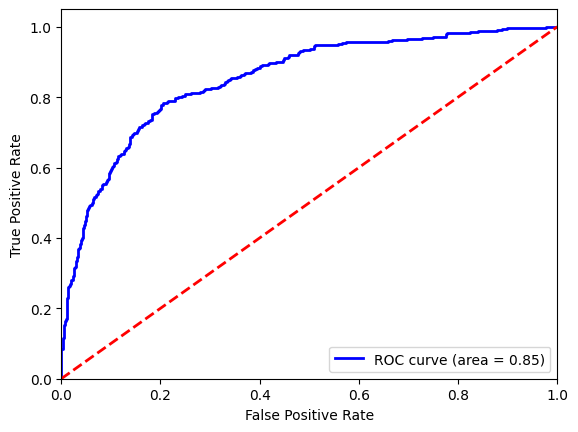

Best hyperparameters CV: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


Best AUC Score (Mean Cross-Validation): 0.9402
Final AUC Score (Test Set): 0.8529


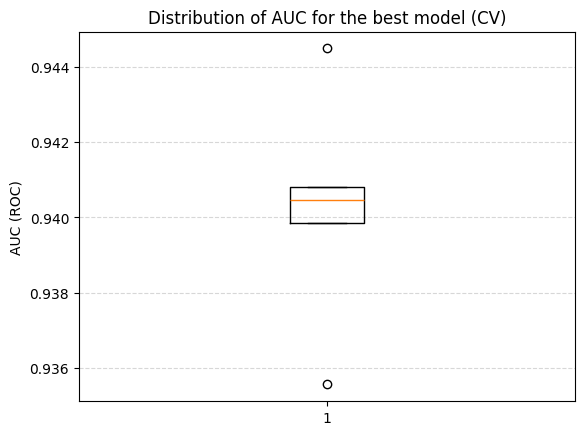

Optimal threshold: 0.4213146257825901
Accuracy: 0.791875
Precision: 0.4893203883495146
Sensitivity (Recall): 0.782608695652174


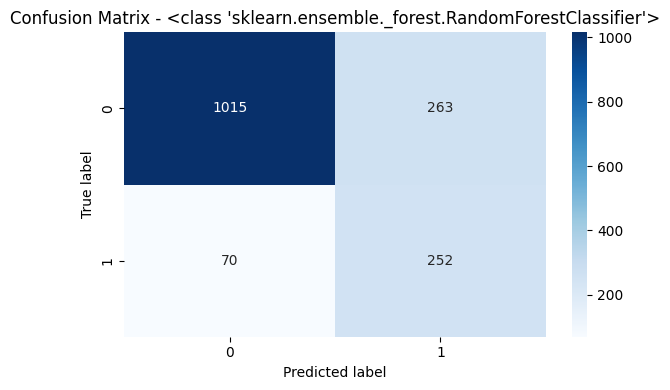

In [30]:
#Grid of hyperparameters
param_grid_RF = {
    'n_estimators': [50, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 5],
    'max_features': ['sqrt', 'log2']
}

best_model_RF, best_score_RF, Y_pred_RF = hyperparameter_tuning(RandomForestClassifier, param_grid_RF, X_res, Y_res, X_test_aug, Y_test)

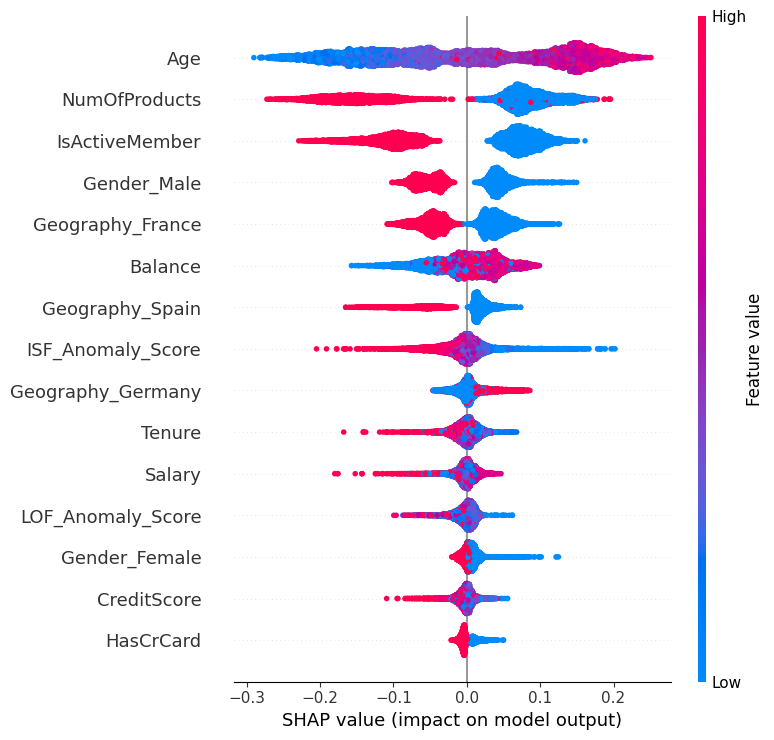

In [31]:
#SHAP values to investigate importance and directionality of each feature
shap.initjs()
explainer = shap.TreeExplainer(best_model_RF)
shap_values = explainer.shap_values(X_res, approximate=False, check_additivity=False)
shap.summary_plot(shap_values[:, :, 1], X_res)

In [32]:
def make_shap_waterfall_plot(shap_values, features, num_display=20):
    '''
    A function for building a SHAP waterfall plot in order to visualize most important
    features in a descending ordere and total percentage of explanability
    '''

    column_list = features.columns
    feature_ratio = (np.abs(shap_values).sum(0) / np.abs(shap_values).sum()) * 100
    column_list = column_list[np.argsort(feature_ratio)[::-1]]
    feature_ratio_order = np.sort(feature_ratio)[::-1]
    cum_sum = np.cumsum(feature_ratio_order)
    column_list = column_list[:num_display]
    feature_ratio_order = feature_ratio_order[:num_display]
    cum_sum = cum_sum[:num_display]

    num_height = 0
    if (num_display >= 20) & (len(column_list) >= 20):
        num_height = (len(column_list) - 20) * 0.4

    fig, ax1 = plt.subplots(figsize=(8, 8 + num_height))
    ax1.plot(cum_sum[::-1], column_list[::-1], c='blue', marker='o')
    ax2 = ax1.twiny()
    ax2.barh(column_list[::-1], feature_ratio_order[::-1], alpha=0.6)

    ax1.grid(True)
    ax2.grid(False)
    ax1.set_xticks(np.arange(0, round(cum_sum.max(), -1)+1, 10))
    ax2.set_xticks(np.arange(0, round(feature_ratio_order.max(), -1)+1, 10))
    ax1.set_xlabel('Cumulative Ratio')
    ax2.set_xlabel('Composition Ratio')
    ax1.tick_params(axis="y", labelsize=13)
    plt.ylim(-1, len(column_list))

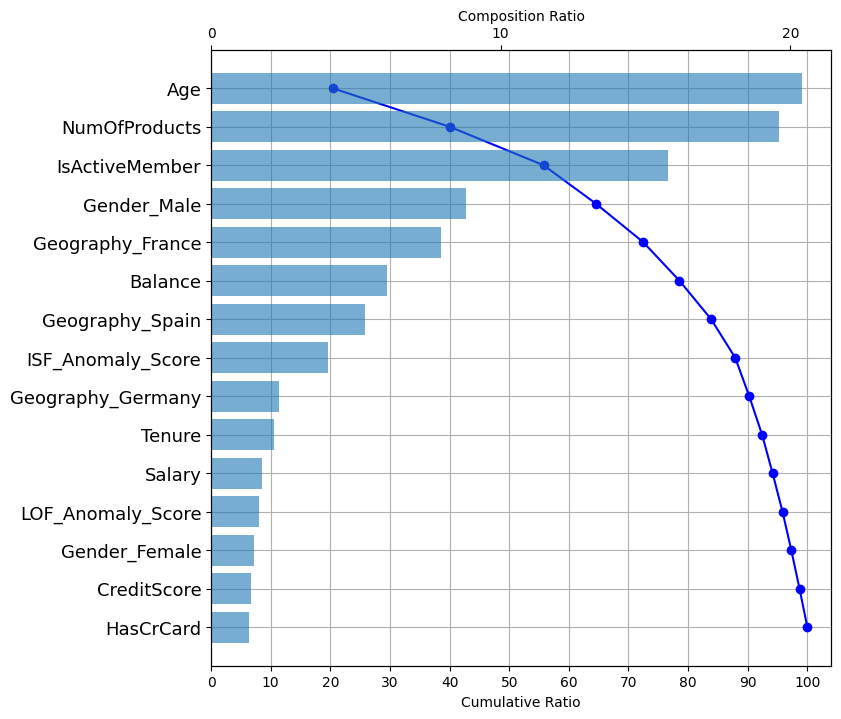

In [33]:
#Plotting importance waterfall
make_shap_waterfall_plot(shap_values[:,:,1], X_res)

In [34]:
#Standard feature importance plot
feature_names = X_res.columns
feature_importances_RF = pd.DataFrame({
    'features': feature_names,
    'Random Forest feature importances': best_model_RF.feature_importances_
})

trace = go.Scatter(
    y=feature_importances_RF['Random Forest feature importances'].values,
    x=feature_importances_RF['features'].values,
    mode='markers',
    marker=dict(
        sizemode='diameter',
        sizeref=1,
        size=25,
        color=feature_importances_RF['Random Forest feature importances'].values,
        colorscale='Portland',
        showscale=True
    ),
    text=feature_importances_RF['features'].values
)

data = [trace]
layout = go.Layout(
    autosize=True,
    title='Random Forest Feature Importance',
    hovermode='closest',
    yaxis=dict(
        title='Feature Importance',
        ticklen=5,
        gridwidth=2
    ),
    showlegend=False
)
fig = go.Figure(data=data, layout=layout)
plt.savefig('RF_FI.png')
fig.show()

<Figure size 640x480 with 0 Axes>

### 6.4 Extra Trees

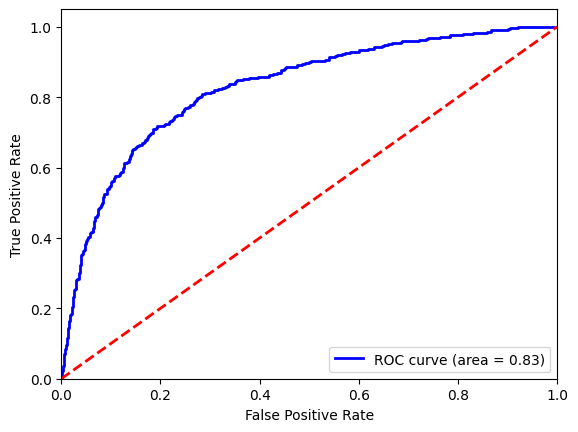

Best hyperparameters CV: {'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 50}


Best AUC Score (Mean Cross-Validation): 0.9210
Final AUC Score (Test Set): 0.8281


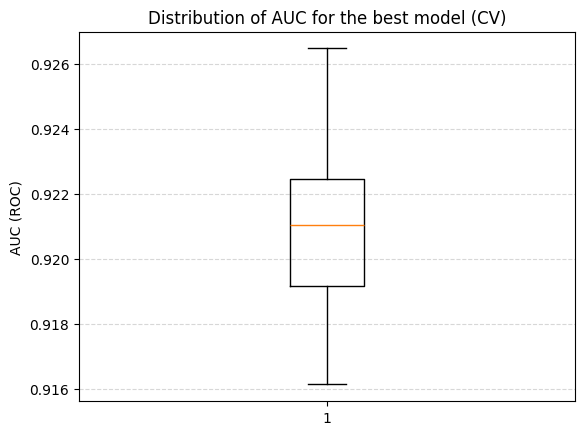

Optimal threshold: 0.4198026204362415
Accuracy: 0.74125
Precision: 0.4240924092409241
Sensitivity (Recall): 0.7981366459627329


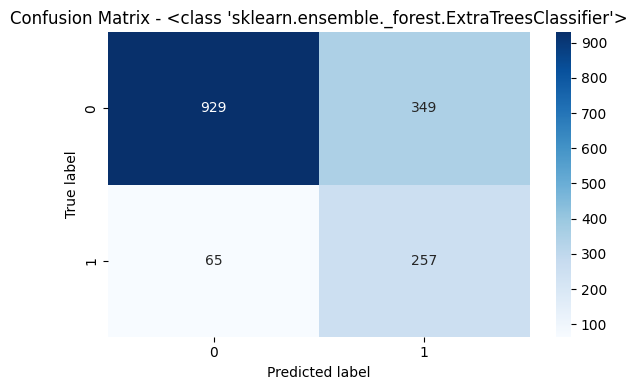

In [35]:
#Hyperparamters grid
param_grid_ET = {
    'n_estimators': [20, 50],
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2']
}

best_model_ET, best_score_ET, Y_pred_ET = hyperparameter_tuning(ExtraTreesClassifier, param_grid_ET, X_res, Y_res, X_test_aug, Y_test)

In [36]:
#Classical feature importance
feature_names = X_res.columns
feature_importances_XT = pd.DataFrame({
    'features': feature_names,
    'Extra Trees feature importances': best_model_ET.feature_importances_
})

trace = go.Scatter(
    y=feature_importances_XT['Extra Trees feature importances'].values,
    x=feature_importances_XT['features'].values,
    mode='markers',
    marker=dict(
        sizemode='diameter',
        sizeref=1,
        size=25,
        color=feature_importances_XT['Extra Trees feature importances'].values,
        colorscale='Portland',
        showscale=True
    ),
    text=feature_importances_XT['features'].values
)

data = [trace]
layout = go.Layout(
    autosize=True,
    title='Extra Trees Feature Importance',
    hovermode='closest',
    yaxis=dict(
        title='Feature Importance',
        ticklen=5,
        gridwidth=2
    ),
    showlegend=False
)
fig = go.Figure(data=data, layout=layout)
plt.savefig('XT_FI.png')
fig.show()

<Figure size 640x480 with 0 Axes>

### 6.5 AdaBoost

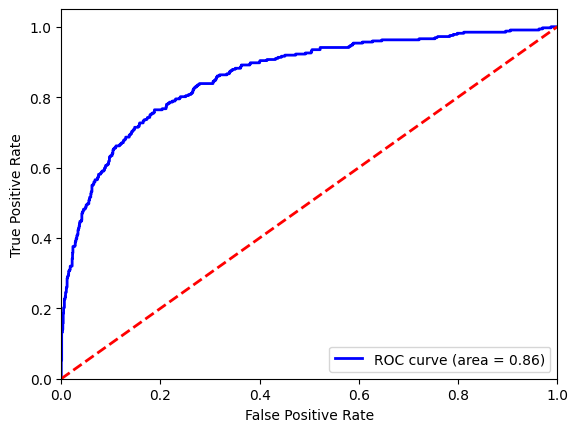

Best hyperparameters CV: {'learning_rate': 1.0, 'n_estimators': 200}


Best AUC Score (Mean Cross-Validation): 0.8844
Final AUC Score (Test Set): 0.8611


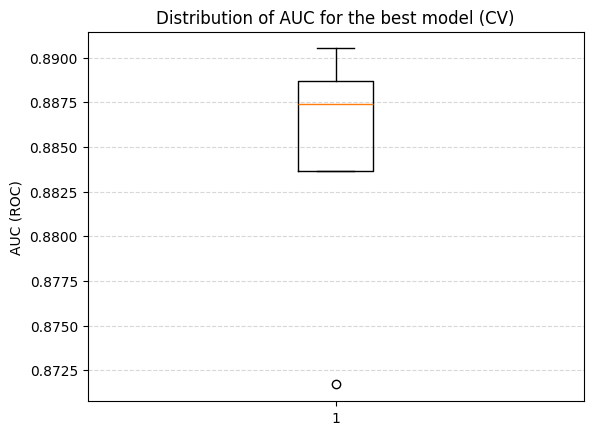

Optimal threshold: 0.4992086568509032
Accuracy: 0.8025
Precision: 0.5061728395061729
Sensitivity (Recall): 0.7639751552795031


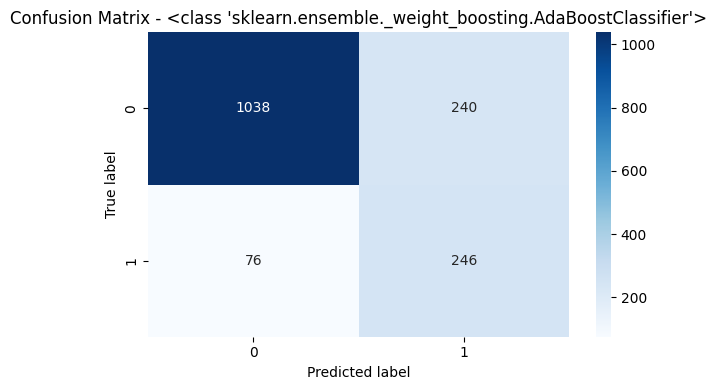

In [37]:
#Hyperparameters grid
param_grid_AB = {
    'n_estimators': [50,100, 200],
    'learning_rate': [0.01, 0.1, 1.0, 2.0]
}

best_model_AB, best_score_AB, Y_best_AB = hyperparameter_tuning(AdaBoostClassifier, param_grid_AB, X_res, Y_res, X_test_aug, Y_test)

In [38]:
#Standard feature importance
feature_names = X_res.columns
feature_importances_AB = pd.DataFrame({
    'features': feature_names,
    'AdaBoost feature importances': best_model_AB.feature_importances_
})

trace = go.Scatter(
    y=feature_importances_AB['AdaBoost feature importances'].values,
    x=feature_importances_AB['features'].values,
    mode='markers',
    marker=dict(
        sizemode='diameter',
        sizeref=1,
        size=25,
        color=feature_importances_AB['AdaBoost feature importances'].values,
        colorscale='Portland',
        showscale=True
    ),
    text=feature_importances_AB['features'].values
)

data = [trace]
layout = go.Layout(
    autosize=True,
    title='AdaBoost Feature Importance',
    hovermode='closest',
    yaxis=dict(
        title='Feature Importance',
        ticklen=5,
        gridwidth=2
    ),
    showlegend=False
)
fig = go.Figure(data=data, layout=layout)
plt.savefig('AB_FI.png')
fig.show()

<Figure size 640x480 with 0 Axes>

### 6.6 Gradient Boosting

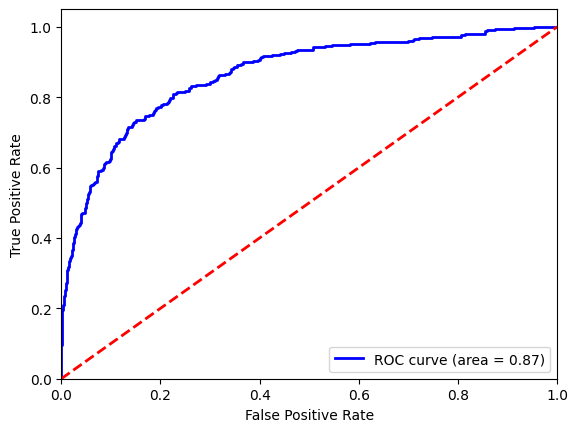

Best hyperparameters CV: {'criterion': 'squared_error', 'learning_rate': 0.05, 'loss': 'exponential', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 1.0}


Best AUC Score (Mean Cross-Validation): 0.9458
Final AUC Score (Test Set): 0.8659


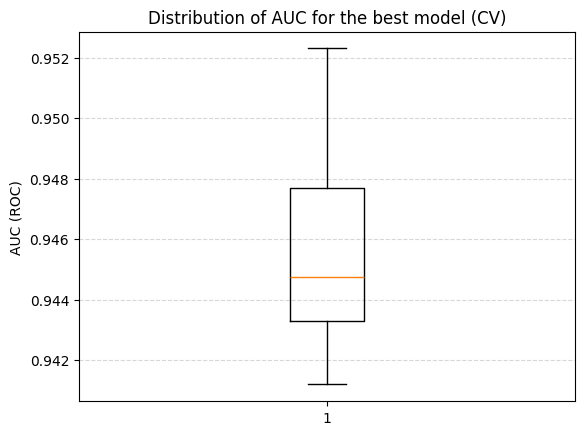

Optimal threshold: 0.3235359633741106
Accuracy: 0.78125
Precision: 0.4744525547445255
Sensitivity (Recall): 0.8074534161490683


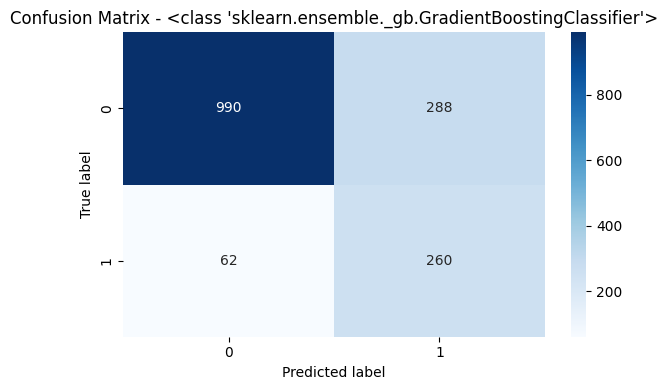

In [39]:
#Hyperparameters grid
param_grid_GB = {
    'loss': ['log_loss', 'exponential'],
    'n_estimators': [200],
    'learning_rate': [0.01, 0.05],
    'criterion': ['friedman_mse', 'squared_error'],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt'],
    'subsample': [0.7, 1.0]
}


best_model_GB, best_score_GB, Y_pred_GB = hyperparameter_tuning(GradientBoostingClassifier, param_grid_GB, X_res, Y_res, X_test_aug, Y_test)

#{'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.1, 'loss': 'exponential', 'max_depth': 3,
 #'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
 #'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_iter_no_change': None,
 #'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}



In [40]:
import plotly.graph_objects as go

#Feature importance
feature_names = X_res.columns
feature_importances_GB = pd.DataFrame({
    'features': feature_names,
    'Gradient Boosting feature importances': best_model_GB.feature_importances_
})

trace = go.Scatter(
    y=feature_importances_GB['Gradient Boosting feature importances'].values,
    x=feature_importances_GB['features'].values,
    mode='markers',
    marker=dict(
        sizemode='diameter',
        sizeref=1,
        size=25,
        color=feature_importances_GB['Gradient Boosting feature importances'].values,
        colorscale='Portland',
        showscale=True
    ),
    text=feature_importances_GB['features'].values
)

data = [trace]
layout = go.Layout(
    autosize=True,
    title='Gradient Boosting Feature Importance',
    hovermode='closest',
    yaxis=dict(
        title='Feature Importance',
        ticklen=5,
        gridwidth=2
    ),
    showlegend=False
)
fig = go.Figure(data=data, layout=layout)
plt.savefig('GB_FI.png')
fig.show()

<Figure size 640x480 with 0 Axes>

### 6.7 LGBM, XGB, CATB

[LightGBM] [Info] Number of positive: 5113, number of negative: 5113
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000316 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1835
[LightGBM] [Info] Number of data points in the train set: 10226, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


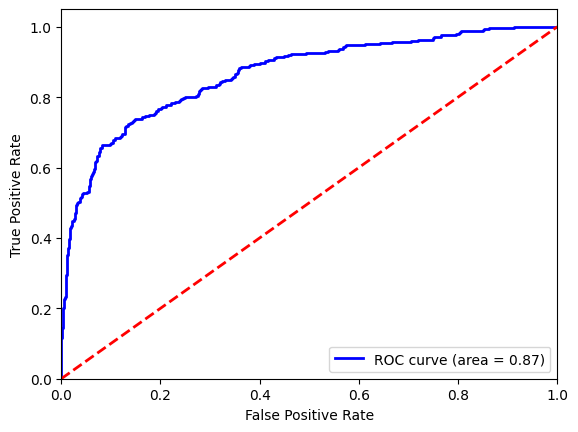

Best hyperparameters CV: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31, 'reg_alpha': 0, 'reg_lambda': 0.5, 'subsample': 0.7}


Best AUC Score (Mean Cross-Validation): 0.9666
Final AUC Score (Test Set): 0.8662


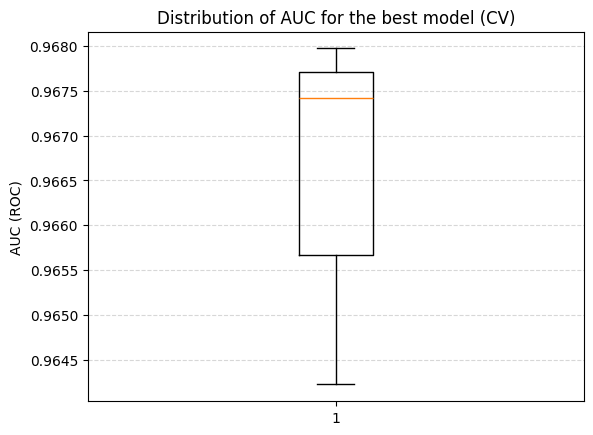

Optimal threshold: 0.3345337326916143
Accuracy: 0.829375
Precision: 0.5573770491803278
Sensitivity (Recall): 0.7391304347826086


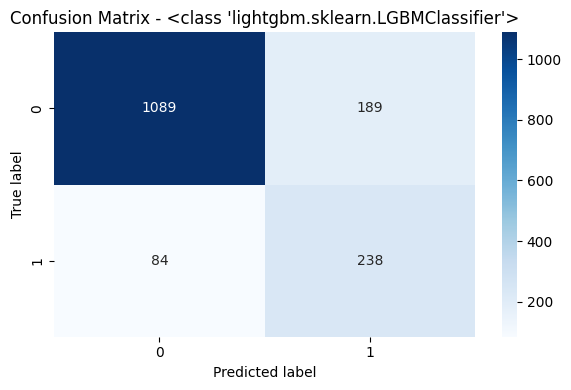

In [41]:
#Hyperparameter grid for LGBM
param_grid_LGBM = {
    'n_estimators': [200],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'learning_rate': [0.03, 0.05],
    'reg_alpha': [0],
    'reg_lambda': [0.5]
}

best_model_LGBM, best_score_LGBM, Y_pred_LGBM = hyperparameter_tuning(LGBMClassifier, param_grid_LGBM, X_res, Y_res, X_test_aug, Y_test)

#Best params
#{'random_state': 42, 'verbose': -1, 'boosting_type': 'gbdt', 'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': -1,
#'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31, 'reg_alpha': 0, 'reg_lambda': 0.5, 'subsample': 0.7}


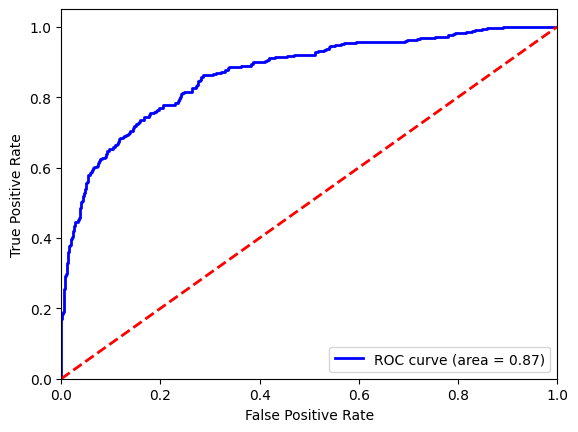

Best hyperparameters CV: {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 1.0, 'subsample': 0.9}


Best AUC Score (Mean Cross-Validation): 0.9575
Final AUC Score (Test Set): 0.8686


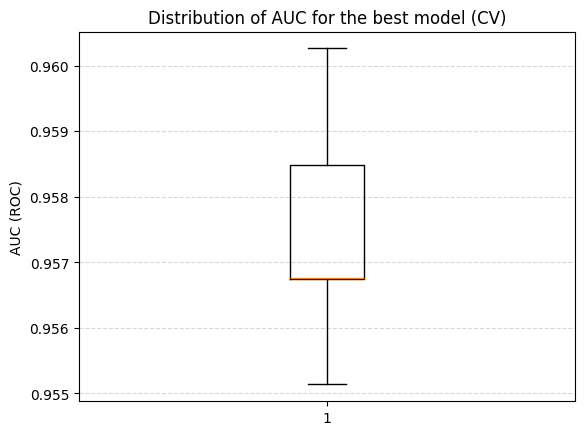

Optimal threshold: 0.35419926047325134
Accuracy: 0.796875
Precision: 0.4969939879759519
Sensitivity (Recall): 0.7701863354037267


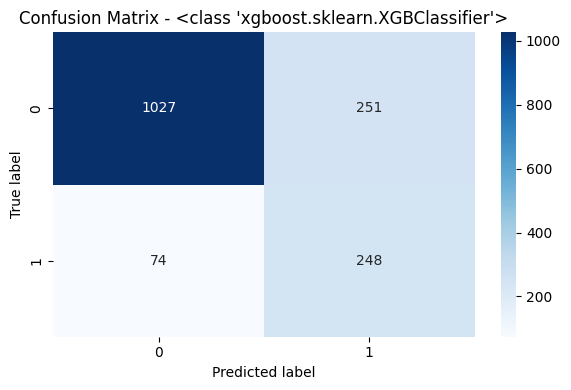

In [42]:
#Hyperparameter grid for XGB
param_grid_XGB = {
    'n_estimators': [200],
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'gamma': [0, 0.1],
    'reg_lambda': [1.0, 2.0],
    'reg_alpha': [0, 0.5],
    'learning_rate': [0.03, 0.05]
}

best_model_XGB, best_score_XGB, Y_pred_XGB = hyperparameter_tuning(XGBClassifier, param_grid_XGB, X_res, Y_res, X_test_aug, Y_test)

#Best params
#{'random_state': 42, 'eval_metric': 'logloss', 'tree_method': 'hist', 'use_label_encoder': False, 'colsample_bytree': 0.7,
#'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 200, 'reg_alpha': 0,
#'reg_lambda': 1.0, 'subsample': 0.9}

0:	learn: 0.6679677	total: 50.9ms	remaining: 10.1s
1:	learn: 0.6444083	total: 53.8ms	remaining: 5.32s
2:	learn: 0.6251878	total: 57.5ms	remaining: 3.77s
3:	learn: 0.6063570	total: 60.7ms	remaining: 2.97s
4:	learn: 0.5919257	total: 63.5ms	remaining: 2.48s
5:	learn: 0.5770660	total: 66.5ms	remaining: 2.15s
6:	learn: 0.5648322	total: 69.5ms	remaining: 1.92s
7:	learn: 0.5534187	total: 72.3ms	remaining: 1.74s
8:	learn: 0.5431581	total: 75.2ms	remaining: 1.6s
9:	learn: 0.5332768	total: 78.2ms	remaining: 1.48s
10:	learn: 0.5228016	total: 81ms	remaining: 1.39s
11:	learn: 0.5147556	total: 83.9ms	remaining: 1.31s
12:	learn: 0.5073844	total: 87ms	remaining: 1.25s
13:	learn: 0.5013315	total: 90ms	remaining: 1.2s
14:	learn: 0.4955135	total: 92.8ms	remaining: 1.14s
15:	learn: 0.4909296	total: 95.7ms	remaining: 1.1s
16:	learn: 0.4849574	total: 98.6ms	remaining: 1.06s
17:	learn: 0.4799830	total: 101ms	remaining: 1.02s
18:	learn: 0.4754298	total: 104ms	remaining: 993ms
19:	learn: 0.4707326	total: 107ms

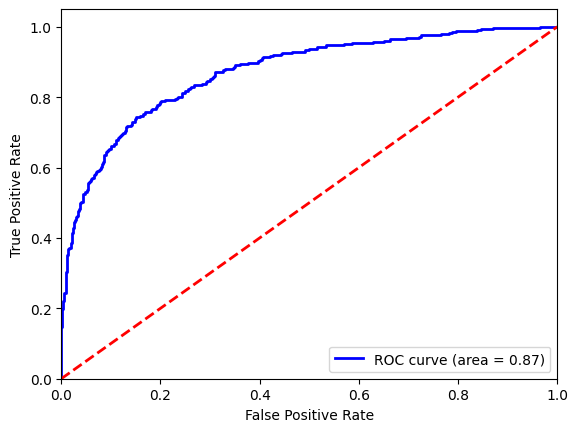

Best hyperparameters CV: {'border_count': 64, 'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.05, 'n_estimators': 200}


Best AUC Score (Mean Cross-Validation): 0.9576
Final AUC Score (Test Set): 0.8718


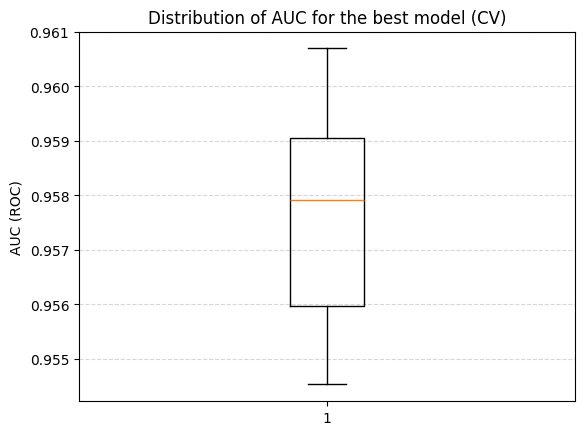

Optimal threshold: 0.318463835558796
Accuracy: 0.7975
Precision: 0.4980392156862745
Sensitivity (Recall): 0.7888198757763976


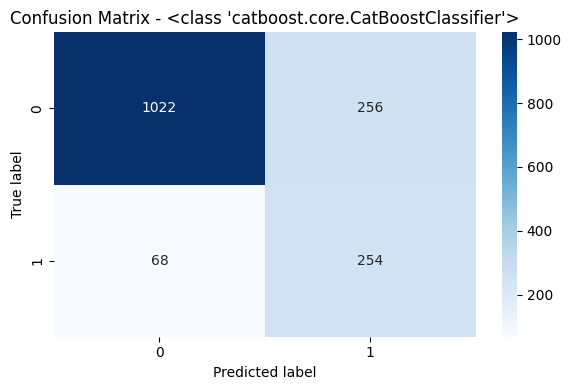

In [43]:
#Hyperparameter grid for CatBoost
param_grid_CAT = {
    'n_estimators': [200],
    'depth': [4, 6],
    'learning_rate': [0.03, 0.05],
    'l2_leaf_reg': [3, 5],
    'border_count': [64, 128],
}

best_model_CAT, best_score_CAT, Y_pred_CAT = hyperparameter_tuning(CatBoostClassifier, param_grid_CAT, X_res, Y_res, X_test_aug, Y_test)

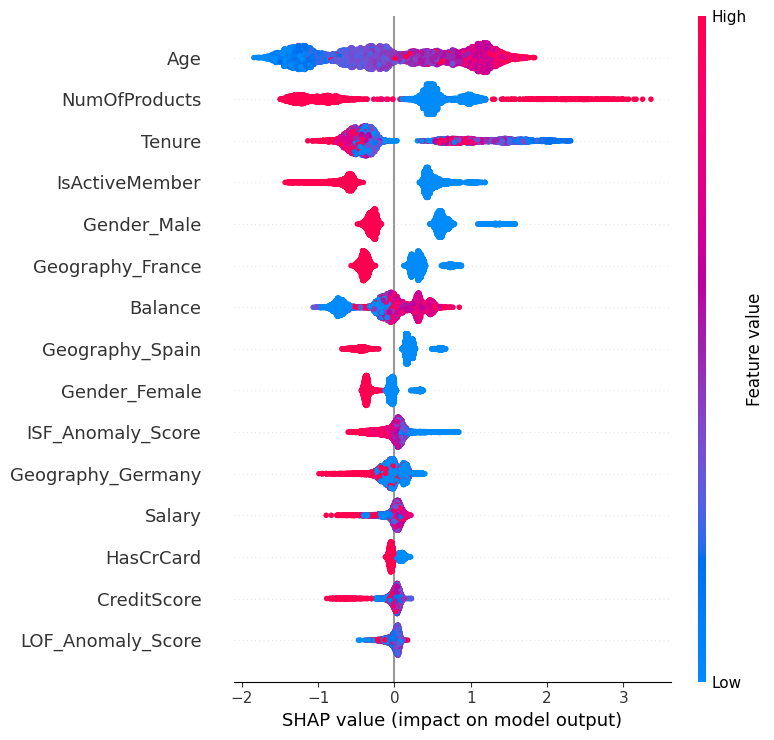

In [44]:
#SHAP values for CAT model
explainer_cat = shap.TreeExplainer(best_model_CAT)
shap_value_cat = explainer_cat.shap_values(X_res, approximate=False, check_additivity=False)
shap.summary_plot(shap_value_cat[:,:], X_res)

### 6.8 Summary of the feature importances and barplot of their means.

In [45]:
#Mean of the feature importance of Random Forest, Extra Trees, AdaBoost and Gradient Boost
feature_importance = feature_importances_RF.merge(feature_importances_XT, on='features') \
                                  .merge(feature_importances_AB, on='features') \
                                  .merge(feature_importances_GB, on='features')

feature_importance['Mean feature importances'] = feature_importance[
    ['Random Forest feature importances', 'Extra Trees feature importances',
     'AdaBoost feature importances', 'Gradient Boosting feature importances']
].mean(axis=1)

feature_importance.head(10)

,features,Random Forest feature importances,Extra Trees feature importances,AdaBoost feature importances,Gradient Boosting feature importances,Mean feature importances
0,CreditScore,0.046307,0.025790,0.092678,0.030279,0.048763
1,Age,0.239193,0.146198,0.278697,0.258982,0.230768
2,Tenure,0.051402,0.038735,0.144038,0.102903,0.084269
3,Balance,0.100544,0.080185,0.014136,0.088360,0.070806
4,NumOfProducts,0.170748,0.207555,0.162014,0.175208,0.178882
5,HasCrCard,0.009016,0.023533,0.010166,0.006048,0.012191
6,IsActiveMember,0.095607,0.159557,0.049966,0.093738,0.099717
7,Salary,0.049851,0.034434,0.090238,0.035246,0.052442
8,Geography_France,0.030148,0.057239,0.034848,0.026557,0.037198
9,Geography_Germany,0.023665,0.042556,0.000000,0.028743,0.023741


In [46]:
#Plot of the mean feature importance
y = feature_importance['Mean feature importances'].values
x = feature_importance['features'].values
data = [go.Bar(
            x= x,
             y= y,
            width = 0.5,
            marker=dict(
               color = feature_importance['Mean feature importances'].values,
            colorscale='Portland',
            showscale=True,
            reversescale = False
            ),
            opacity=0.6
        )]

layout= go.Layout(
    autosize= True,
    title= 'Barplots of Mean Feature Importance',
    hovermode= 'closest',
    yaxis=dict(
        title= 'Feature Importance',
        ticklen= 5,
        gridwidth= 2
    ),
    showlegend= False
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='bar-direct-labels')
plt.savefig('FI_MEAN.png')

<Figure size 640x480 with 0 Axes>

In [47]:
#We study the correlation between the best ensemble models, RF, XT, AB and GB (same just used for feature importance)
predictions_df = pd.DataFrame({
    'RF': Y_pred_RF,
    'XT': Y_pred_ET,
    'AB': Y_best_AB,
    'GB': Y_pred_GB})


In [48]:
correlation_matrix = predictions_df.corr()

fig = px.imshow(correlation_matrix,
                title='Correlation Heatmap of Model Predictions',
                labels=dict(x='Models', y='Models', color='Correlation'),
                x=correlation_matrix.columns,
                y=correlation_matrix.columns,
               color_continuous_scale = 'blues')


plt.savefig('MODEL_CORR.png')
fig.show()

<Figure size 640x480 with 0 Axes>

### 6.9 Stacking

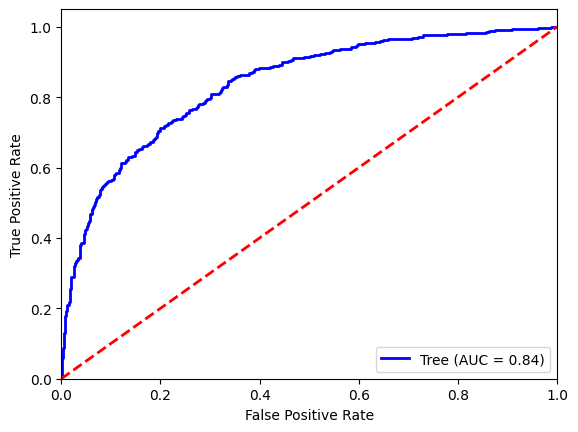

Optimal threshold: 0.10864808617264994
Accuracy: 0.774375
Precision: 0.4629981024667932
Sensitivity (Recall): 0.7577639751552795


In [49]:
#Stacking Classifier
estimators = [
    ('gnb', GaussianNB()),
    ('lda', LDA()),
    ('qda', QDA()),
    ('logreg', LogisticRegression(max_iter=200)),
    ('dt', DecisionTreeClassifier()),
    ('rf', RandomForestClassifier()),
    ('et', ExtraTreesClassifier()),
    ('ab', AdaBoostClassifier()),
    ('gb', GradientBoostingClassifier())
]

meta_model = LogisticRegression(max_iter=200)

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,
    passthrough=True
)

stacking_model.fit(X_res, Y_res)
Y_prob_test_STK = stacking_model.predict_proba(X_test_aug)[:, 1]
fpr_STK, tpr_STK, thresholds_STK = roc_curve(Y_test, Y_prob_test_STK)
roc_auc_STK = auc(fpr_STK, tpr_STK)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'{name} (AUC = {roc_auc_STK:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.savefig('ROC_STK.png')
plt.show()

distances_STK = np.sqrt((1 - tpr_STK)**2 + (fpr_STK)**2)
optimal_idx_STK = np.argmin(distances_STK)
optimal_threshold_STK = thresholds_STK[optimal_idx_STK]

Y_pred_optimal_STK = (Y_prob_test_STK >= optimal_threshold_STK).astype(int)

accuracy_STK = metrics.accuracy_score(Y_test, Y_pred_optimal_STK)
precision_STK = metrics.precision_score(Y_test, Y_pred_optimal_STK)
recall_STK = metrics.recall_score(Y_test, Y_pred_optimal_STK)

print(f'Optimal threshold: {optimal_threshold_STK}')
print(f'Accuracy: {accuracy_STK}')
print(f'Precision: {precision_STK}')
print(f'Sensitivity (Recall): {recall_STK}')

## Chapter 7 – Deep Learning Approach

Even though the project is focused on ML techniques we also want to try a basic DL approach.

We implement a fairly simple Multilayer Perceptron to see if the performance are similar or much better.

In [50]:
#Extract Train set as 60% of total
X_trainNN, X_second, Y_trainNN, Y_second = train_test_split(X, Y, test_size=0.4, stratify=Y,
                                                    random_state=5)

#Training and Testing set are each 20% of the total dataset
X_valNN, X_testNN, Y_valNN, Y_testNN = train_test_split(X_second, Y_second, test_size=0.5, stratify=Y_second,
                                                    random_state=5)

#Performing z-score standardization
X_mean = X_trainNN[numerical_features].mean()
X_std = X_trainNN[numerical_features].std()

X_trainNN[numerical_features] = (X_trainNN[numerical_features] - X_mean) / X_std
X_valNN[numerical_features] = (X_valNN[numerical_features] - X_mean) / X_std
X_testNN[numerical_features] = (X_testNN[numerical_features] - X_mean) / X_std

#Initializing Borderline SMOTE, seed for reproducibility
sm = BorderlineSMOTE(random_state=5)

#Applying Borderline SMOTE only on Training set
X_resNN, Y_resNN = sm.fit_resample(X_trainNN, Y_trainNN)

namesNN = X_resNN.columns


Configuration: [8, 4, 2] Validation AUC: 0.8372141058913871
Configuration: [64, 16, 4, 2] Validation AUC: 0.8369856822091972
Configuration: [32, 8, 2] Validation AUC: 0.8327744243237201
Configuration: [32, 16, 4, 2] Validation AUC: 0.8335617570155232
Best AUC on validation set: 0.8372141058913871 with configuration: [8, 4, 2]


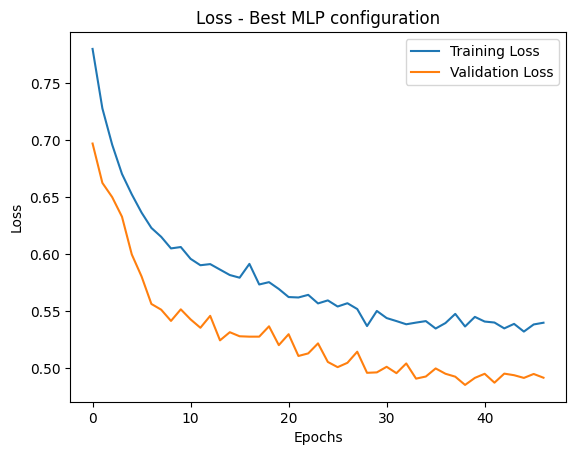

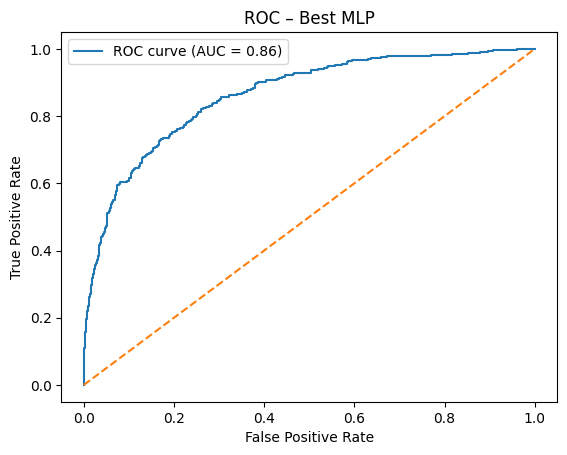

Neural Network Classification Results on Test Set:
Optimal threshold: 0.49500152
Accuracy: 0.76
Precision: 0.447098976109215
Recall (Sensitivity): 0.8136645962732919
Confusion Matrix:
 [[954 324]
 [ 60 262]]


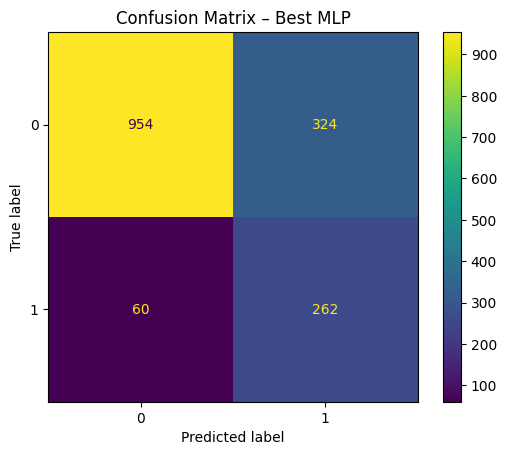

In [59]:
from tensorflow.keras import optimizers, callbacks, metrics

#Function to build the Multilayer Perceptron
def build_mlp(layer_sizes, input_dim, dropout_rate=0.3, l2_reg=1e-4, lr=1e-3):
    model = Sequential()

    #Layers
    model.add(Dense(
        layer_sizes[0],
        input_dim=input_dim,
        activation='relu',
        kernel_regularizer=l2(l2_reg)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))


    for units in layer_sizes[1:]:
        model.add(Dense(
            units,
            activation='relu',
            kernel_regularizer=l2(l2_reg)
        ))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))


    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[
            metrics.AUC(name='auc'),
            metrics.Recall(name='recall'),
            metrics.Precision(name='precision'),
            'accuracy'
        ]
    )
    return model

#Grid of configurations
configurations = [
    [8, 4, 2],
    [64, 16, 4, 2],
    [32, 8, 2],
    [32, 16, 4, 2]
]

#Initialising best model variables
best_model = None
best_val_auc = -np.inf
best_configuration = None
best_history = None

input_dim = X_resNN.shape[1]

#Fitting MLP for different configurations
for layers_conf in configurations:
    model = build_mlp(layers_conf, input_dim)

    es = callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=10,
        restore_best_weights=True
    )
    rlrop = callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        factor=0.5,
        patience=3,
        min_lr=1e-5
    )

    history = model.fit(
        X_resNN, Y_resNN,
        epochs=50,
        batch_size=32,
        validation_data=(X_valNN, Y_valNN),
        callbacks=[es, rlrop],
        verbose=0
    )

    Y_val_pred_prob = model.predict(X_valNN, verbose=0)
    val_auc = roc_auc_score(Y_valNN, Y_val_pred_prob)

    print('Configuration:', layers_conf, 'Validation AUC:', val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model = model
        best_configuration = layers_conf
        best_history = history


#Printinf best performance
print('Best AUC on validation set:', best_val_auc,
      'with configuration:', best_configuration)

plt.figure()
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss - Best MLP configuration')
plt.show()


Y_test_pred_prob = best_model.predict(X_testNN, verbose=0)

fpr_NN, tpr_NN, thresholds = roc_curve(Y_testNN, Y_test_pred_prob)
test_auc = roc_auc_score(Y_testNN, Y_test_pred_prob)

plt.figure()
plt.plot(fpr_NN, tpr_NN, label=f'ROC curve (AUC = {test_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC – Best MLP')
plt.show()

distances_NN = np.sqrt((1 - tpr_NN)**2 + (fpr_NN)**2)
optimal_idx_NN = np.argmin(distances_NN)
optimal_threshold_NN = thresholds[optimal_idx_NN]

Y_test_pred = (Y_test_pred_prob >= optimal_threshold_NN).astype(int)

accuracy = accuracy_score(Y_testNN, Y_test_pred)
precision = precision_score(Y_testNN, Y_test_pred)
recall = recall_score(Y_testNN, Y_test_pred)
conf_matrix = confusion_matrix(Y_testNN, Y_test_pred)

print("Neural Network Classification Results on Test Set:")
print("Optimal threshold:", optimal_threshold_NN)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall (Sensitivity):", recall)
print("Confusion Matrix:\n", conf_matrix)

cm = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])
cm.plot()
plt.title('Confusion Matrix – Best MLP')
plt.show()


## Chapter 8 – Fairness in AI

In [63]:
#Fairness in AI, computing metrics Indepence, Sufficiency and Separation
#we calculate the metrics on the AdaBoost model, it is the model we have chosen as best in our analysis

#Making target variable and predictions are in array form
y_true = np.array(Y_test)
y_pred = np.array(Y_best_AB)

#Creating masks to separate Male and Female
mask_male = (X_test["Gender_Male"].values == 1)
mask_female = (X_test["Gender_Female"].values == 1)

def group_confusion_and_fairness(y_true, y_pred, group_mask, group_name="group"):

    y_t = y_true[group_mask]
    y_p = y_pred[group_mask]

    if len(y_t) == 0:
        print(f"No sample for the group {group_name}")
        return None

    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    N = tn + fp + fn + tp

    def safe_div(num, den):
        return num / den if den != 0 else np.nan

    #Independence
    # P(ŷ=1 | A=group)
    p_pred_pos = safe_div(tp + fp, N)

    #Separation
    # TPR = P(ŷ=1 | Y=1, A=group)
    tpr = safe_div(tp, tp + fn)
    # FPR = P(ŷ=1 | Y=0, A=group)
    fpr = safe_div(fp, fp + tn)

    #Sufficiency
    # PPV = P(Y=1 | ŷ=1, A=group)
    ppv = safe_div(tp, tp + fp)
    # NPV = P(Y=0 | ŷ=0, A=group)
    npv = safe_div(tn, tn + fn)

    metrics_group = {
        "group": group_name,
        "N": N,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        # Independence
        "P_hat1": p_pred_pos,
        # Separation
        "TPR": tpr,
        "FPR": fpr,
        # Sufficiency
        "PPV": ppv,
        "NPV": npv
    }
    return metrics_group

#Applying the fucntion for the two groups
fair_male = group_confusion_and_fairness(y_true, y_pred, mask_male, group_name="Male")
fair_female = group_confusion_and_fairness(y_true, y_pred, mask_female, group_name="Female")

#To analyse the metrics we use the ratio between the Male and Female
def fairness_ratios(m1, m2):
    ratios = {}
    for k in ["P_hat1", "TPR", "FPR", "PPV", "NPV"]:
        v1 = m1[k]
        v2 = m2[k]
        ratios[k + "_ratio_abs"] = v1/v2 if (not np.isnan(v1) and not np.isnan(v2)) else np.nan
    return ratios

if fair_male is not None and fair_female is not None:
    ratios = fairness_ratios(fair_male, fair_female)

    print("=== Ratios di fairness (Male vs Female) ===")
    print("Independence ratio:", ratios["P_hat1_ratio_abs"])
    print("Separation ratio TPR", ratios["TPR_ratio_abs"])
    print("Separation ratio FPR", ratios["FPR_ratio_abs"])
    print("Sufficiency ratio PPV:", ratios["PPV_ratio_abs"])
    print("Sufficiency ratio NPV :", ratios["NPV_ratio_abs"])


=== Ratios di fairness (Male vs Female) ===
Independence ratio: 0.5863830674590762
Separation ratio TPR 0.8865248226950355
Separation ratio FPR 0.5292846715328468
Sufficiency ratio PPV: 0.9952945990180033
Sufficiency ratio NPV : 1.0206979238972675


=== Ratios di fairness (Male vs Female) ===
Independence ratio: 0.866556090310067
Separation ratio TPR 1.028138528138528
Separation ratio FPR 0.975719298245614
Sufficiency ratio PPV: 0.7810828877005347
Sufficiency ratio NPV : 1.0455806763285025
Final AUC Score (Test Set): 0.8579


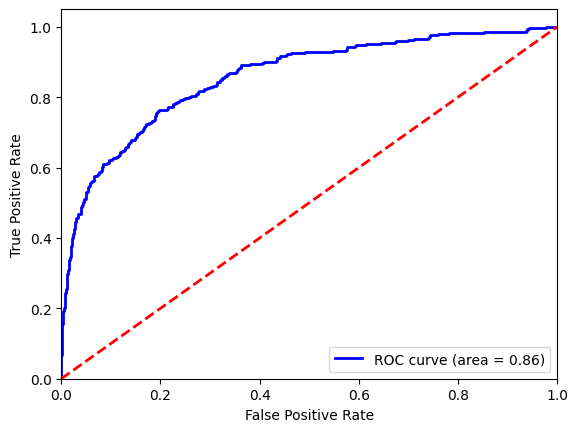

In [64]:
#To improve fairness metrics and eliminate bias we try by re-training the model without the Gender metrics (Fairness through unawareness)

#Train and Test set without the two Gender features
X_train_nogender = X_res.drop(columns=["Gender_Female", "Gender_Male"])
X_test_nogender  = X_test_aug.drop(columns=["Gender_Female", "Gender_Male"])

#Using AdaBoost
ada = AdaBoostClassifier (
    n_estimators = 200,
    learning_rate = 1.0
)

ada.fit(X_train_nogender, Y_res)

#New predictions
Y_pred_base = ada.predict(X_test_nogender)
Y_prob_base = ada.predict_proba(X_test_nogender)[:, 1]
y_pred1 = np.array(Y_pred_base)

fair_male = group_confusion_and_fairness(y_true, y_pred1, mask_male, group_name="Male")
fair_female = group_confusion_and_fairness(y_true, y_pred1, mask_female, group_name="Female")

#Printing new metrics
if fair_male is not None and fair_female is not None:
    ratios = fairness_ratios(fair_male, fair_female)

    print("=== Ratios di fairness (Male vs Female) ===")
    print("Independence ratio:", ratios["P_hat1_ratio_abs"])
    print("Separation ratio TPR", ratios["TPR_ratio_abs"])
    print("Separation ratio FPR", ratios["FPR_ratio_abs"])
    print("Sufficiency ratio PPV:", ratios["PPV_ratio_abs"])
    print("Sufficiency ratio NPV :", ratios["NPV_ratio_abs"])


#Plotting ROC Curve
Y_prob_test_AB = ada.predict_proba(X_test_nogender)[:, 1]
fpr_AB, tpr_AB, thresholds_AB = roc_curve(Y_test, Y_prob_test_AB)
roc_auc_AB = auc(fpr_AB, tpr_AB)
roc_auc = auc(fpr_AB, tpr_AB)

print(f"Final AUC Score (Test Set): {roc_auc:.4f}")

plt.figure()
plt.plot(fpr_AB, tpr_AB, color='blue', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc_AB))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


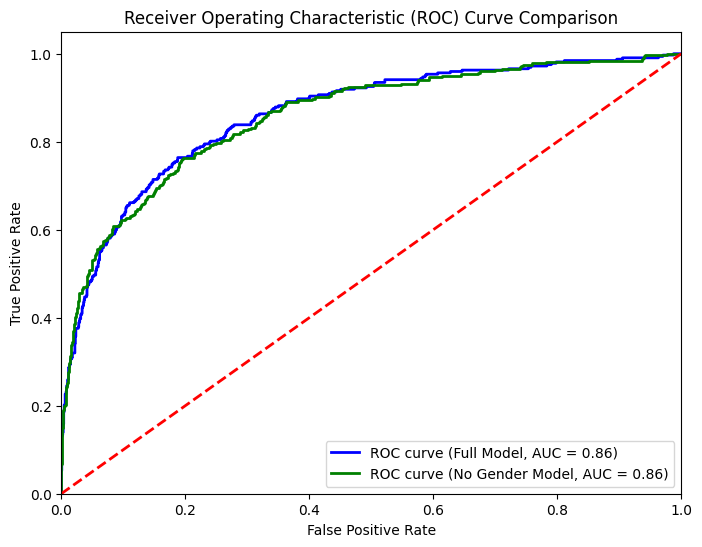

In [65]:
#We finally plot the ROC Curve for both the Gender and No Gender model

#No Gender ROC
Y_prob_test_nogender = ada.predict_proba(X_test_nogender)[:, 1]
fpr_nogender, tpr_nogender, thresholds_nogender = roc_curve(Y_test, Y_prob_test_nogender)
roc_auc_nogender = auc(fpr_nogender, tpr_nogender)

#Gender ROC
Y_prob_test_full = best_model_AB.predict_proba(X_test_aug)[:, 1]
fpr_full, tpr_full, thresholds_full = roc_curve(Y_test, Y_prob_test_full)
roc_auc_full = auc(fpr_full, tpr_full)

#Plot both ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_full, tpr_full, color='blue', lw=2, label='ROC curve (Full Model, AUC = {:.2f})'.format(roc_auc_full))
plt.plot(fpr_nogender, tpr_nogender, color='green', lw=2, label='ROC curve (No Gender Model, AUC = {:.2f})'.format(roc_auc_nogender))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.savefig('roc_curve_comparison.png')